
# EDA — Indicadores e Fatores Associados a Acidentes Fatais
## Base de Acidentes da PRF — `dados_abertos_prfdatatran2025.csv`

Reprodução do roteiro de EDA do módulo de referência (base de vendas), agora aplicado à
**base de dados abertos da Polícia Rodoviária Federal (PRF)** para o ano de 2025.
Indicadores → rankings e séries → análise bivariada orientada a um alvo → combinações de
fatores → gráficos → síntese interpretativa.

**Base de dados:** `dados_abertos_prfdatatran2025.csv` — registros de acidentes de trânsito
nas rodovias federais brasileiras ocorridos em 2025, com colunas de data/hora, UF, BR, km,
município, causa e tipo do acidente, classificação de gravidade, condições da via e do
tempo, e contagens de pessoas/vítimas/veículos envolvidos.

**Problema analítico central:** *Quais fatores estão associados à ocorrência de acidentes
com vítima fatal?*

**Variável-alvo:** `acidente_fatal`
- `1` = o acidente teve **pelo menos 1 morto** (`mortos > 0`), equivalente a
  `classificacao_acidente == "Com Vítimas Fatais"`
- `0` = acidentes sem vítima fatal (`classificacao_acidente` igual a `"Sem Vítimas"` ou
  `"Com Vítimas Feridas"`)

**Unidade de análise:** ocorrência de acidente registrada pela PRF (uma linha do CSV).

> Assim como no módulo de referência (onde o evento problemático era raro frente ao total de
> pedidos), aqui o evento de interesse — acidente **fatal** — também é minoritário diante do
> total de acidentes. O cuidado metodológico é o mesmo: não confundir **volume** com
> **proporção de risco (letalidade)**, e sempre comparar qualquer recorte com a **taxa
> global** de referência.

In [1]:
# Importação da biblioteca PANDAS
# Essencial para leitura, organização e manipulação tabular dos dados (DataFrames)
import pandas as pd

# Importação da biblioteca NUMPY
# Usada como apoio para operações numéricas (médias, arredondamentos, tratamento de NaN)
import numpy as np

# Importação do MATPLOTLIB (módulo pyplot)
# Biblioteca de visualização usada para construir os gráficos da análise exploratória
import matplotlib.pyplot as plt

# Importação do módulo de formatação de eixos do matplotlib
# Usado para exibir os eixos dos gráficos em formato de porcentagem (%), facilitando a leitura
import matplotlib.ticker as mtick

In [2]:
# Configuração de exibição de números decimais do pandas
# Formata todos os números float exibidos em tabelas com separador de milhar e 2 casas decimais
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Ajuste da resolução (DPI) padrão dos gráficos
# Deixa os gráficos exibidos no notebook com melhor nitidez
plt.rcParams["figure.dpi"] = 110

In [3]:
# Paleta de cores usada em todos os gráficos da EDA (categórica, fixa por papel)
# Mantemos as mesmas cores ao longo do notebook para que cada categoria seja sempre
# reconhecida pela mesma cor (evita repintar séries quando um filtro muda a seleção)
C_BLUE, C_ORANGE, C_AQUA   = "#2a78d6", "#eb6834", "#1baf7a"
C_YELLOW, C_MAGENTA        = "#eda100", "#e87ba4"
C_GREEN, C_VIOLET, C_RED   = "#008300", "#4a3aa7", "#e34948"
C_INK, C_MUTED             = "#0b0b0b", "#898781"

# Dicionário de mapeamento UF -> Região
# A base da PRF não traz a coluna "região" diretamente — apenas a UF —, então
# construímos esse mapeamento manualmente para permitir rankings e séries por região
UF_REGIAO = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte",
    "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste",
    "PB": "Nordeste", "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}

In [4]:
# Caminho do arquivo CSV da base de acidentes da PRF
# Leitura do arquivo CSV da base de acidentes
# A base da PRF é disponibilizada com ";" como separador de colunas e acentuação em
# Latin-1 (ISO-8859-1) — por isso os parâmetros sep=";" e encoding="latin1"
df = pd.read_csv("dados_abertos_prf-datatran2025.csv", sep=";", encoding="latin1")

# Conversão da coluna de data (formato AAAA-MM-DD) de texto para o tipo datetime
# Necessário para permitir agrupamentos por mês/ano e cálculos de série temporal
df["data_inversa"] = pd.to_datetime(df["data_inversa"])

In [5]:
# Tratamento das colunas numéricas que vêm com vírgula decimal (padrão brasileiro)
# "km", "latitude" e "longitude" chegam como texto (ex.: "225,4") — convertemos a
# vírgula para ponto e transformamos em número (float) para permitir cálculos
for col in ["km", "latitude", "longitude"]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

# Extração da hora do acidente a partir da coluna "horario" (formato HH:MM:SS)
# Usada mais adiante para a série de acidentes por hora do dia
df["hora"] = pd.to_datetime(df["horario"], format="%H:%M:%S", errors="coerce").dt.hour

# Criação da coluna "regiao" aplicando o dicionário UF -> Região definido acima
df["regiao"] = df["uf"].map(UF_REGIAO)

# Criação da coluna "mes" no formato Ano-Mês (ex.: 2025-01)
# Agrupa cada data de acidente no seu respectivo mês, base para a série temporal
df["mes"] = df["data_inversa"].dt.to_period("M").astype(str)

In [6]:
# Exibição do formato da base (linhas, colunas)
# Primeira conferência: confirma quantos acidentes e quantas colunas foram carregados
print(df.shape)

# Exibição das 5 primeiras linhas da base
# Permite uma inspeção visual inicial da estrutura e do conteúdo dos dados
df.head(5)

(72529, 33)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos,veiculos,latitude,longitude,regional,delegacia,uop,hora,regiao,mes
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225.00,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,...,1,2,-23.49,-46.54,SPRF-SP,DEL01-SP,UOP01-DEL01-SP,6,Sudeste,2025-01
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,546.20,PENAFORTE,Pista esburacada,Colisão frontal,...,1,6,-7.81,-39.08,SPRF-CE,DEL05-CE,UOP03-DEL05-CE,7,Nordeste,2025-01
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,88.20,CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,...,3,2,-23.18,-50.64,SPRF-PR,DEL07-PR,UOP05-DEL07-PR,8,Sul,2025-01
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74.00,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,1,2,-25.37,-49.04,SPRF-PR,DEL01-PR,UOP02-DEL01-PR,11,Sul,2025-01
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471.00,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,...,2,4,-16.47,-43.43,SPRF-MG,DEL12-MG,UOP01-DEL12-MG,9,Sudeste,2025-01


In [7]:
# Exibição dos tipos de dados (dtype) de cada coluna
# Importante para confirmar se colunas numéricas (mortos, feridos, km) e de data foram
# reconhecidas corretamente, e não interpretadas como texto (object)
print("Tipos de dados:")
print(df.dtypes)

Tipos de dados:
id                                 int64
data_inversa              datetime64[ns]
dia_semana                        object
horario                           object
uf                                object
br                                 int64
km                               float64
municipio                         object
causa_acidente                    object
tipo_acidente                     object
classificacao_acidente            object
fase_dia                          object
sentido_via                       object
condicao_metereologica            object
tipo_pista                        object
tracado_via                       object
uso_solo                          object
pessoas                            int64
mortos                             int64
feridos_leves                      int64
feridos_graves                     int64
ilesos                             int64
ignorados                          int64
feridos                            int64


In [8]:
# Contagem de valores ausentes (NaN) por coluna
# Etapa obrigatória de qualidade de dados: identifica onde existem lacunas
# antes de calcular qualquer indicador
print("Valores ausentes por coluna (apenas colunas com algum ausente):")
nulos = df.isna().sum()
print(nulos[nulos > 0])

Valores ausentes por coluna (apenas colunas com algum ausente):
classificacao_acidente     1
regional                   2
delegacia                 22
uop                       38
dtype: int64


In [9]:
# Verificação do período coberto pela base
# Mostra a menor e a maior data de acidente, delimitando a janela temporal da análise
print("Período coberto:", df["data_inversa"].min().date(), "a", df["data_inversa"].max().date())

Período coberto: 2025-01-01 a 2025-12-31


## 2. Estatística descritiva e indicadores globais

In [10]:
# Contagem de acidentes por classificação de gravidade
# Primeira visão da variável que confirma o alvo (acidente_fatal): quantos acidentes são
# Sem Vítimas, Com Vítimas Feridas ou Com Vítimas Fatais
print("Classificação do acidente (contagem):")
print(df["classificacao_acidente"].value_counts(dropna=False))

Classificação do acidente (contagem):
classificacao_acidente
Com Vítimas Feridas    56181
Sem Vítimas            11138
Com Vítimas Fatais      5209
NaN                        1
Name: count, dtype: int64


In [11]:
# Criação da variável-alvo "acidente_fatal"
# Transforma a contagem de mortos em uma variável binária (0/1) que sinaliza o evento de
# interesse — aqui, acidente com pelo menos 1 vítima fatal
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)

In [12]:
# Cálculo do total de acidentes na base
# Denominador que será usado em todos os percentuais globais e segmentados
total_acidentes = len(df)

In [13]:
# Cálculo do total de acidentes com vítima fatal
# Soma da coluna binária acidente_fatal (soma de 1s = quantidade de acidentes fatais)
total_fatais = int(df["acidente_fatal"].sum())

In [14]:
# Cálculo do percentual global de acidentes fatais
# Razão entre acidentes fatais e o total de acidentes — a TAXA GLOBAL DE REFERÊNCIA
# que será comparada com todos os cruzamentos feitos nos blocos seguintes
pct_fatais = total_fatais / total_acidentes

In [15]:
# Cálculo do total de mortos e da letalidade a cada 100 acidentes
# "mortos" soma todas as vítimas fatais (um acidente pode ter mais de 1 morto);
# letalidade_100 é uma métrica de gravidade global mais fina do que só a % de acidentes fatais
total_mortos = int(df["mortos"].sum())
letalidade_100 = total_mortos / total_acidentes * 100

In [16]:
# Cálculo da média de mortos por acidente fatal
# Considera apenas os acidentes que registraram pelo menos uma vítima fatal;
# o indicador mostra quantas mortes ocorreram, em média, em cada acidente fatal
media_mortos_acidente_fatal = total_mortos / total_fatais

In [17]:
# Cálculo de indicadores complementares de volume: feridos, ilesos, veículos e pessoas
# envolvidas — dão a dimensão humana e material do total de ocorrências
total_feridos        = int(df["feridos"].sum())
total_feridos_graves = int(df["feridos_graves"].sum())
total_ilesos          = int(df["ilesos"].sum())
total_veiculos         = int(df["veiculos"].sum())
total_pessoas          = int(df["pessoas"].sum())

In [18]:
# Montagem da tabela-resumo de indicadores globais
# Consolida todos os indicadores calculados acima em uma única tabela, pronta para
# ser incluída no relatório exploratório
indicadores_globais = pd.DataFrame({
    "indicador": [
        "Total de acidentes", "Acidentes com vítima fatal", "% de acidentes fatais",
        "Total de mortos", "Mortos por 100 acidentes", "Média de pessoas mortas por acidente fatal",
        "Total de feridos", "Total de feridos graves", "Total de ilesos",
        "Total de veículos envolvidos", "Total de pessoas envolvidas",
        "Média de pessoas por acidente", "Média de veículos por acidente",

    ],
    "valor": [
        total_acidentes, total_fatais, f"{pct_fatais:.2%}",
        total_mortos, f"{letalidade_100:.2f}", f"{total_mortos/total_fatais:.2f}",
        total_feridos, total_feridos_graves, total_ilesos,
        total_veiculos, total_pessoas,
        f"{total_pessoas/total_acidentes:.2f}", f"{total_veiculos/total_acidentes:.2f}",

    ],
})

# Exibição da tabela final de indicadores globais
indicadores_globais

,indicador,valor
0,Total de acidentes,72529
1,Acidentes com vítima fatal,5210
2,% de acidentes fatais,7.18%
3,Total de mortos,6043
4,Mortos por 100 acidentes,8.33
5,Média de pessoas mortas por acidente fatal,1.16
6,Total de feridos,83550
7,Total de feridos graves,20018
8,Total de ilesos,76406
9,Total de veículos envolvidos,144922


In [19]:
# Estatística descritiva das variáveis numéricas de contagem de vítimas/veículos
# describe() traz contagem, média, desvio-padrão, mínimo, quartis e máximo;
# complementamos com mediana e assimetria (skew), úteis para variáveis de contagem
# muito concentradas em zero (ex.: "mortos")
num_cols = ["pessoas", "mortos", "feridos_leves", "feridos_graves", "ilesos", "feridos", "veiculos", "km"]
estat_descritiva = df[num_cols].describe().T
estat_descritiva["mediana"] = df[num_cols].median()
estat_descritiva["assimetria"] = df[num_cols].skew()
estat_descritiva

,count,mean,std,min,25%,50%,75%,max,mediana,assimetria
pessoas,"72,529.00",2.60,2.26,1.00,2.00,2.00,3.00,76.00,2.00,11.79
mortos,"72,529.00",0.08,0.34,0.00,0.00,0.00,0.00,16.00,0.00,7.50
feridos_leves,"72,529.00",0.88,1.04,0.00,0.00,1.00,1.00,41.00,1.00,7.25
feridos_graves,"72,529.00",0.28,0.61,0.00,0.00,0.00,0.00,22.00,0.00,5.10
ilesos,"72,529.00",1.05,1.83,0.00,0.00,1.00,1.00,71.00,1.00,14.44
feridos,"72,529.00",1.15,1.14,0.00,1.00,1.00,1.00,49.00,1.00,8.93
veiculos,"72,529.00",2.00,1.13,1.00,1.00,2.00,2.00,82.00,2.00,7.54
km,"72,529.00",260.04,227.92,0.00,76.00,192.50,411.00,"1,257.00",192.50,0.99


## BLOCO 2 — Frequências, rankings e séries simples

**Objetivo:** organizar a distribuição dos acidentes respondendo: onde, quando e em que
condições ocorrem mais acidentes — e mais acidentes fatais?

In [20]:
def ranking(var, ordenar_por="acidentes"):
    t = df.groupby(var, observed=True).agg(
        acidentes=("id", "count"),
        acidentes_fatais=("acidente_fatal", "sum"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
    )

    t["pct_acidentes"] = t["acidentes"] / total_acidentes
    t["pct_fatal"] = df.groupby(var, observed=True)["acidente_fatal"].mean()

    t = t.sort_values(ordenar_por, ascending=False)

    return t

## 3. Rankings — onde os eventos acontecem

#### 3.1 Frequência 1 - Por UF
Panorama nacional: quais UFs concentram mais acidentes?


In [21]:
# Frequência 1 - Panorama nacional: onde os acidentes acontecem?
# Mostra em quais estados estão concentrados os acidentes
print("Frequência geral: acidentes, mortos, feriados e percentuais de acidentes e fatalidade por UF (todas as 27 unidades da federação):")
display(ranking("uf"))

Frequência geral: acidentes, mortos, feriados e percentuais de acidentes e fatalidade por UF (todas as 27 unidades da federação):


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
uf,,,,,,
MG,9570,647,765,12002,0.13,0.07
SC,8186,374,434,9400,0.11,0.05
PR,7630,511,593,8537,0.11,0.07
RJ,6428,306,330,7659,0.09,0.05
RS,4899,275,327,5553,0.07,0.06
SP,4683,205,221,4988,0.06,0.04
BA,4108,476,583,5023,0.06,0.12
GO,3196,247,308,3557,0.04,0.08
PE,3013,302,336,3348,0.04,0.10


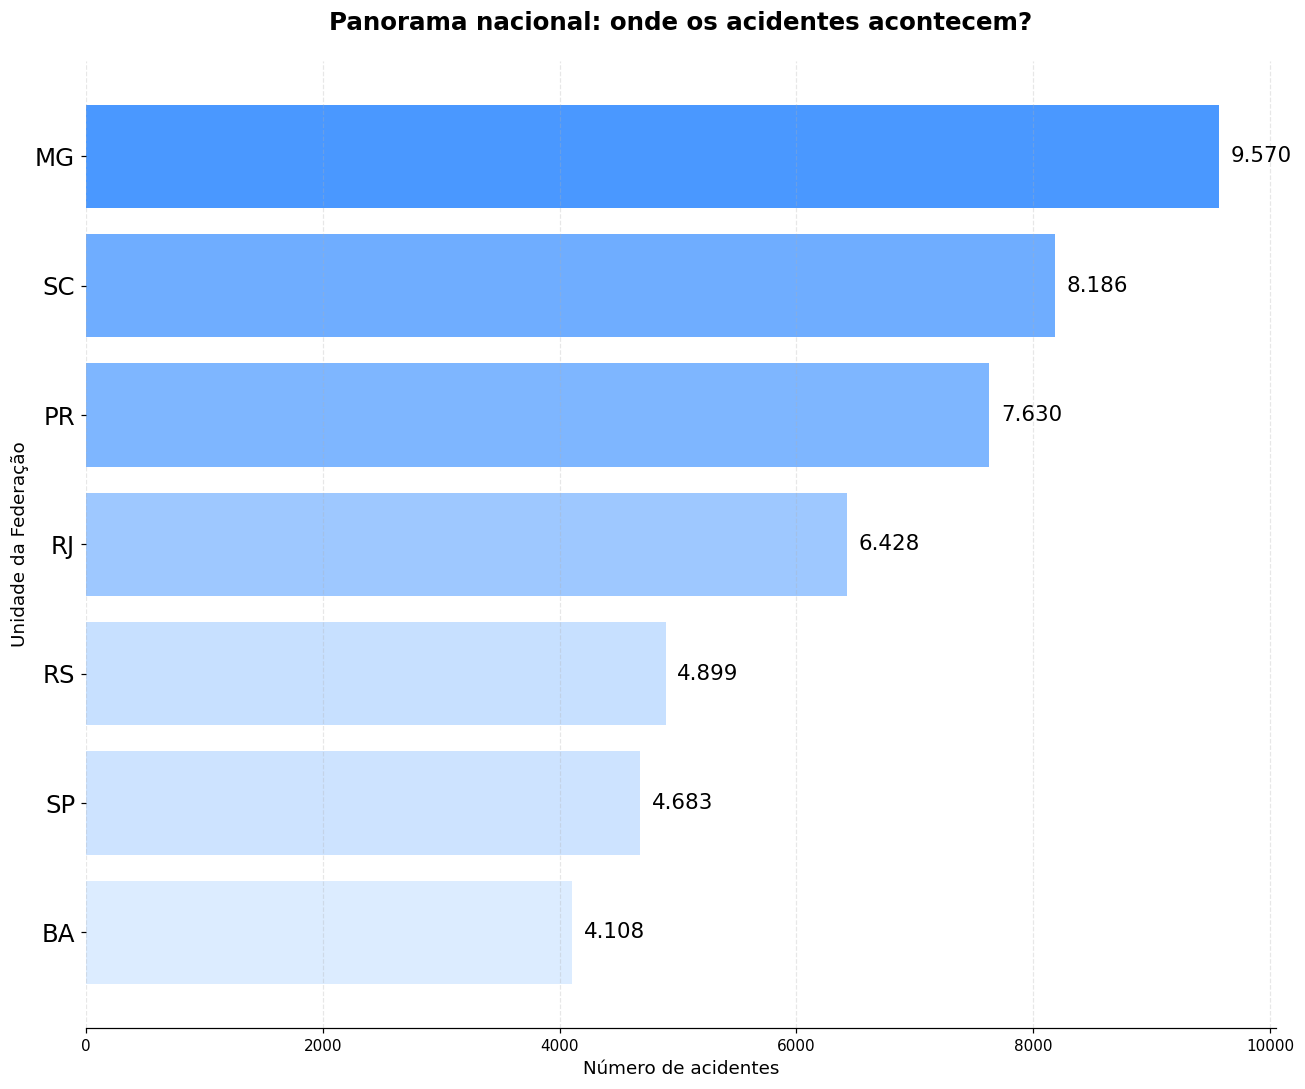

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Gera o ranking por UF
ranking_uf = ranking("uf").head(7)

# Cria um gradiente baseado na cor #4a98ff
cmap = LinearSegmentedColormap.from_list(
    "gradiente_azul",
    ["#dcecff", "#4a98ff"]
)

# Normalização dos valores
norm = plt.Normalize(
    ranking_uf["acidentes"].min(),
    ranking_uf["acidentes"].max()
)

# Cores das barras
cores = cmap(norm(ranking_uf["acidentes"].values))

# Cria o gráfico
plt.figure(figsize=(12, 10))

plt.barh(
    ranking_uf.index,
    ranking_uf["acidentes"],
    color=cores
)

# Maior valor no topo
plt.gca().invert_yaxis()

# Título
plt.title(
    "Panorama nacional: onde os acidentes acontecem?",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Número de acidentes", fontsize=12)
plt.ylabel("Unidade da Federação", fontsize=12)

# Tamanho da fonte das siglas dos estados
plt.tick_params(
    axis="y",
    labelsize=16
)

# Valores ao final das barras
for i, valor in enumerate(ranking_uf["acidentes"]):
    plt.text(
        valor + ranking_uf["acidentes"].max() * 0.01,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=14
    )

# Grade
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Remove bordas
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

Decidi abrir a análise fazendo um panorama geral nacional, para observar os números de acidentes, mortos, feridos e o percentual de cada estado brasileiro e o que eles representam diante dos percentuais nacionais de acidentes e acidentes fatais. A partir disso, quero identificar quais estados apresentam números que possam ser investigados mais afundo a fim de obter insights com relação à fatalidade de acidentes nas estradas brasileiras.

Quais estados concentram maior número de acidentes?
Quais concentram maior número de acidentes fatais?
E quais apresentam maiores taxas de fatalidade?

Inicialmente, observo Minas Gerais números altos em todas as variáveis, o que desperta o interesse em saber que fatores contribuem para que esse estado lidere os índices nacionais. Com relação a dados gerais, que não estão na planilha da PRF, mas que podem ser utilizados para obter insights nesta análise, MG apresenta:

Área: 586.514 km² (4º maior estado do Brasil)
População: 20,54 milhões (Censo 2022, inferior apenas à de São Paulo, que tem 46,1 milhões)
População estimada em 2025: 21,39 milhões
Maior malha rodoviária do país: 272 mil km.

###3.2 Frequência 2 - Por Região

In [23]:
# Frequência 2 - Panorama regional: onde os acidentes acontecem?
# Mostra em quais regiões do país estão concentrados os acidentes e qual a letalidade de cada uma
print("Ranking por região:")
display(ranking("regiao").sort_values("acidentes", ascending=False))

Ranking por região:


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
regiao,,,,,,
Sudeste,23323,1303,1477,27943,0.32,0.06
Sul,20715,1160,1354,23490,0.29,0.06
Nordeste,16019,1675,1939,18337,0.22,0.10
Centro-Oeste,8497,630,748,9228,0.12,0.07
Norte,3975,442,525,4552,0.05,0.11


Um segundo levantamento geral, porém mais concentrado, permite observar o panorama geral pode região. A ideia é a mesma do levantamento por estados, porém, compartimentando mais os dados. Como se trata de uma análise nacional, e que levam em consideração dados de estradas federais, é interessante ter um recorte regionalizado, uma vez que essas BRs cortam o Brasil. É possível perceber que o Sudeste lidera em números gerais, principalmente por causa da contribuição do estado de MG. Além disso, é uma região considerada o centro econômico do país, o que proporciona um grande movimento nas estradas. Contudo, também chamam atenção os números da região Sul, que tem apenas três estados, mas tem o segundo maior registro de acidentes do Brasil. Pela estimativa do IBGE para 2025, a Região Sul tinha 31.310.809 habitantes. Isso representa aproximadamente 14,7% da população brasileira. Além disso, é a menor das cinco grandes regiões brasileiras em extensão territorial. É um dado que nos alerta para uma análise mais aprofundada sobre os acidentes nessa região. A região Nordeste, por sua vez, desperta o interesse por ter o maior número mortes nas estradas, mesmo estando em terceiro lugar na quantidade de acidentes. É importante verificar que fatores tornam os acidentes na região Nordeste mais fatais.

##3.3 Frequência 3 - Por tipos de acidente

In [24]:
# Frequência 3 - Panorama nacional: quais os tipos dos acidentes nas estradas brasileiras?
print("Frequência dos tipos de acidente:")
display(ranking("tipo_acidente"))

Frequência dos tipos de acidente:


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
tipo_acidente,,,,,,
Colisão traseira,14360,619,683,16376,0.20,0.04
Saída de leito carroçável,10209,605,700,11638,0.14,0.06
Colisão transversal,9306,427,481,12015,0.13,0.05
Colisão lateral mesmo sentido,7885,212,228,8839,0.11,0.03
Tombamento,6351,268,293,7241,0.09,0.04
Colisão com objeto,5109,297,323,4952,0.07,0.06
Colisão frontal,4739,1396,1863,7596,0.07,0.29
Queda de ocupante de veículo,3450,87,89,4038,0.05,0.03
Atropelamento de Pedestre,3057,902,919,2846,0.04,0.30


In [25]:
# Frequência 3 (filtrado) - Panorama nacional: quais os tipos dos acidentes com maior percentual de mortes nas estradas brasileiras
# (considerando os tipos de acidentes com pelo menos 100 registros)?

tabela_tipos = ranking("tipo_acidente")

# Mantém apenas os tipos com pelo menos 100 acidentes
tabela_tipos = tabela_tipos[tabela_tipos["acidentes"] >= 100]

# Ordena pela proporção de acidentes fatais, do maior para o menor
tabela_tipos = tabela_tipos.sort_values("pct_fatal", ascending=False)

print("Frequência dos tipos de acidente (mínimo de 100 ocorrências):")
display(tabela_tipos.style.format({
    "pct_acidentes": "{:.2%}",
    "pct_fatal": "{:.2%}"
}))

Frequência dos tipos de acidente (mínimo de 100 ocorrências):


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
tipo_acidente,,,,,,
Atropelamento de Pedestre,3057,902,919,2846,4.21%,29.51%
Colisão frontal,4739,1396,1863,7596,6.53%,29.46%
Colisão lateral sentido oposto,2152,212,255,2824,2.97%,9.85%
Eventos atípicos,287,23,24,293,0.40%,8.01%
Atropelamento de Animal,1133,68,74,1267,1.56%,6.00%
Saída de leito carroçável,10209,605,700,11638,14.08%,5.93%
Colisão com objeto,5109,297,323,4952,7.04%,5.81%
Capotamento,1373,63,74,1827,1.89%,4.59%
Colisão transversal,9306,427,481,12015,12.83%,4.59%


Uma análise dos tipos de acidentes pode oferecer um panorama sobre a dinâmica das mortes nas rodovias brasileiras. A observação dos dados mostra que os acidentes mais recorrentes não são, necessariamente, os mais fatais. A partir da identificação dos tipos de ocorrência com maior proporção de mortes, é possível aprofundar a investigação sobre os fatores associados a esses acidentes e, consequentemente, discutir alternativas para preveni-los. Nesse contexto, quais condições fazem com que as colisões frontais e os atropelamentos estejam entre os tipos de acidentes mais fatais nas rodovias brasileiras?

##3.3.2 Frequência 4 - Por causa de acidente

In [26]:
# Frequência 4 - Panorama nacional: quais as principais causas dos acidentes?
print("Top 15 causas de acidente mais fatais:")
display(ranking("causa_acidente", ordenar_por="pct_fatal").head(15))

Top 15 causas de acidente mais fatais:


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
causa_acidente,,,,,,
Suicídio (presumido),190,106,111,98,0.00,0.56
Pedestre andava na pista,606,250,252,465,0.01,0.41
Entrada inopinada do pedestre,667,203,209,582,0.01,0.30
Transitar na contramão,2475,736,961,3452,0.03,0.30
Participar de racha,22,6,7,29,0.00,0.27
Pedestre cruzava a pista fora da faixa,525,130,133,534,0.01,0.25
Falta de acostamento,60,11,11,58,0.00,0.18
Modificação proibida,11,2,2,12,0.00,0.18
Pedestre - Ingestão de álcool/ substâncias psicoativas,150,27,28,163,0.00,0.18


In [27]:
# Frequência 4 (filtrado) - Panorama nacional: quais as principais causas dos acidentes?
# (considerando os tipos de acidentes com pelo menos 100 registros)?

tabela_causas = ranking("causa_acidente")

# Mantém apenas os tipos com pelo menos 100 acidentes
tabela_causas = tabela_causas[tabela_causas["acidentes"] >= 100]

# Ordena pela proporção de acidentes fatais, do maior para o menor
tabela_causas = tabela_causas.sort_values("pct_fatal", ascending=False)

print("Frequência das causas de acidente (mínimo de 100 ocorrências):")
display(tabela_causas.style.format({
    "pct_acidentes": "{:.2%}",
    "pct_fatal": "{:.2%}"
}))

Frequência das causas de acidente (mínimo de 100 ocorrências):


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
causa_acidente,,,,,,
Suicídio (presumido),190,106,111,98,0.26%,55.79%
Pedestre andava na pista,606,250,252,465,0.84%,41.25%
Entrada inopinada do pedestre,667,203,209,582,0.92%,30.43%
Transitar na contramão,2475,736,961,3452,3.41%,29.74%
Pedestre cruzava a pista fora da faixa,525,130,133,534,0.72%,24.76%
Pedestre - Ingestão de álcool/ substâncias psicoativas,150,27,28,163,0.21%,18.00%
Ultrapassagem Indevida,1770,302,404,2760,2.44%,17.06%
Iluminação deficiente,157,23,24,189,0.22%,14.65%
Deficiência do Sistema de Iluminação/Sinalização,165,24,24,201,0.23%,14.55%


##3.3.3 Por BRs - Ranking 1

In [28]:
# Ranking das rodovias por proporção de acidentes fatais
# Considera apenas BRs com no mínimo 100 acidentes

ranking_br = ranking("br", ordenar_por="pct_fatal")

ranking_br = (
    ranking_br[
        (ranking_br["acidentes"] >= 100) &
        (ranking_br["pct_fatal"] > 0.0718)
        ]
    .sort_values("pct_fatal", ascending=False)
)


# Exibe a porcentagem de acidentes fatais formatada
ranking_br["pct_acidentes"] = ranking_br["pct_acidentes"].map(lambda x: f"{x:.2%}")
ranking_br["pct_fatal"] = ranking_br["pct_fatal"].map(lambda x: f"{x:.2%}")

print("Rodovias (BR) com no mínimo 100 acidentes, ordenadas pela % de acidentes fatais:")
display(ranking_br)

Rodovias (BR) com no mínimo 100 acidentes, ordenadas pela % de acidentes fatais:


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
br,,,,,,
423,183,40,59,229,0.25%,21.86%
242,283,54,73,392,0.39%,19.08%
222,581,106,128,594,0.80%,18.24%
10,506,86,95,604,0.70%,17.00%
408,141,23,24,132,0.19%,16.31%
407,283,44,48,318,0.39%,15.55%
110,339,51,60,462,0.47%,15.04%
316,1236,182,201,1421,1.70%,14.72%
135,559,82,105,607,0.77%,14.67%


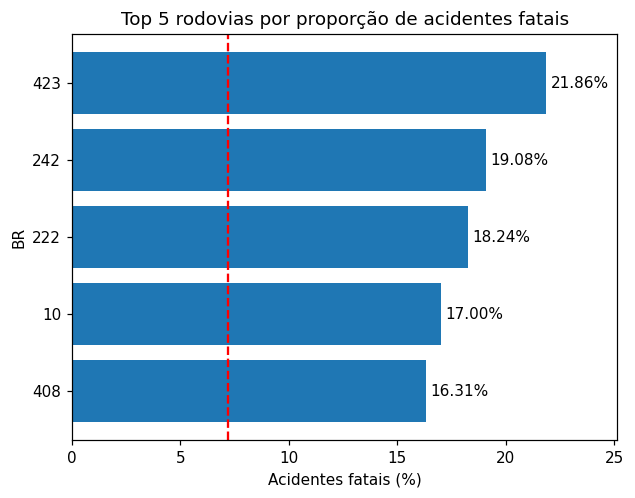

In [29]:
grafico = ranking("br", ordenar_por="pct_fatal")

grafico = grafico[grafico["acidentes"] >= 100].head(5).sort_values("pct_fatal")

plt.barh(grafico.index.astype(str), grafico["pct_fatal"] * 100)

for i, valor in enumerate(grafico["pct_fatal"] * 100):
    plt.text(valor + 0.2, i, f"{valor:.2f}%", va="center")

plt.axvline(7.18, linestyle="--", color="red")

plt.title("Top 5 rodovias por proporção de acidentes fatais")
plt.xlabel("Acidentes fatais (%)")
plt.ylabel("BR")
plt.xlim(0, grafico["pct_fatal"].max() * 100 * 1.15)
plt.show()

In [30]:
# Ranking das rodovias por volume de acidentes
# Considera apenas BRs com no mínimo 100 acidentes

ranking_br = ranking("br", ordenar_por="acidentes")

ranking_br = (
    ranking_br[ranking_br["acidentes"] >= 100]
    .sort_values("acidentes", ascending=False)
)

# Exibe a porcentagem de acidentes fatais formatada
ranking_br["pct_acidentes"] = ranking_br["pct_acidentes"].map(lambda x: f"{x:.2%}")
ranking_br["pct_fatal"] = ranking_br["pct_fatal"].map(lambda x: f"{x:.2%}")


print("Top 18 rodovias (BR) com no mínimo 100 acidentes, por volume de acidentes:")
display(ranking_br.head(30))

Top 18 rodovias (BR) com no mínimo 100 acidentes, por volume de acidentes:


,acidentes,acidentes_fatais,mortos,feridos,pct_acidentes,pct_fatal
br,,,,,,
101,13014,682,760,15033,17.94%,5.24%
116,11021,638,708,12268,15.20%,5.79%
40,3502,180,214,4183,4.83%,5.14%
381,3496,171,190,4166,4.82%,4.89%
153,2789,226,282,3117,3.85%,8.10%
163,2519,173,210,2603,3.47%,6.87%
364,2264,153,173,2515,3.12%,6.76%
277,2157,134,152,2492,2.97%,6.21%
262,1769,148,169,2137,2.44%,8.37%


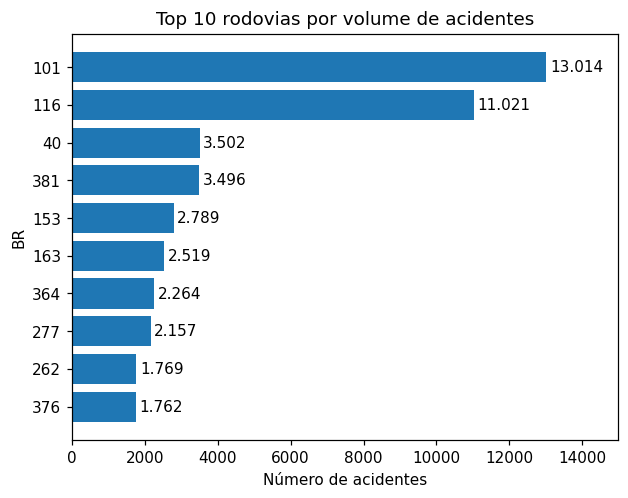

In [31]:
grafico = ranking("br", ordenar_por="acidentes")

grafico = grafico[grafico["acidentes"] >= 100].head(10).sort_values("acidentes")

plt.barh(grafico.index.astype(str), grafico["acidentes"])

for i, valor in enumerate(grafico["acidentes"]):
    plt.text(valor + 100, i, f"{valor:,}".replace(",", "."), va="center")

plt.xlim(0, grafico["acidentes"].max() * 1.15)

plt.title("Top 10 rodovias por volume de acidentes")
plt.xlabel("Número de acidentes")
plt.ylabel("BR")
plt.show()

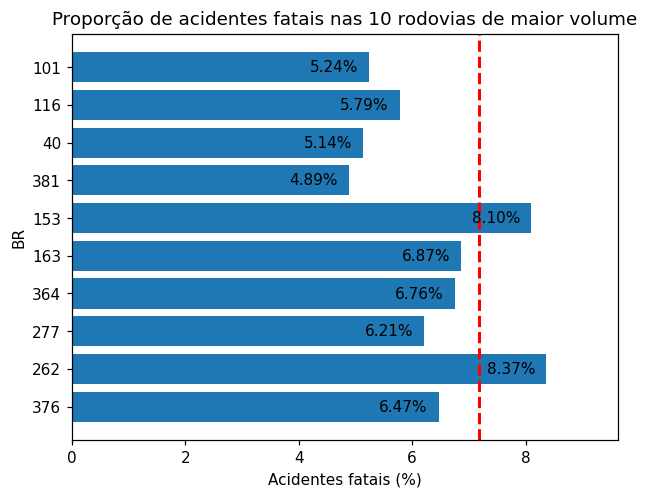

In [32]:
grafico = ranking("br", ordenar_por="acidentes")

grafico = grafico[grafico["acidentes"] >= 100].head(10)

grafico = grafico.iloc[::-1]

plt.barh(grafico.index.astype(str), grafico["pct_fatal"] * 100)

plt.axvline(7.18, linestyle="--", color="red", linewidth=2)

for i, valor in enumerate(grafico["pct_fatal"] * 100):
    plt.text(valor - 0.2, i, f"{valor:.2f}%", va="center", ha="right")

plt.title("Proporção de acidentes fatais nas 10 rodovias de maior volume")
plt.xlabel("Acidentes fatais (%)")
plt.ylabel("BR")
plt.xlim(0, grafico["pct_fatal"].max() * 100 * 1.15)

plt.show()

##4. Séries temporais

###4.1 Série mensal

In [33]:
# Criação da série mensal: agrupamento dos acidentes por mês, com quatro métricas
# calculadas simultaneamente
serie_mensal = df.groupby("mes", observed=True).agg(
    acidentes=("id", "count"),                # quantidade de acidentes no mês
    fatais=("acidente_fatal", "sum"),          # quantidade de acidentes fatais no mês
    mortos=("mortos", "sum"),                  # total de mortos no mês
    feridos=("feridos", "sum"),                # total de feridos no mês
)

# Cálculo do percentual mensal de acidentes fatais
# Permite observar se a proporção de acidentes fatais oscila ao longo dos meses
serie_mensal["pct_fatal"] = serie_mensal["fatais"] / serie_mensal["acidentes"]

# Exibição da série mensal completa (janeiro a dezembro de 2025)
serie_mensal

,acidentes,fatais,mortos,feridos,pct_fatal
mes,,,,,
2025-01,5528,359,418,6915,0.06
2025-02,5287,362,412,5974,0.07
2025-03,5960,402,462,6784,0.07
2025-04,5786,414,495,6678,0.07
2025-05,6096,504,574,6834,0.08
2025-06,6122,457,528,6920,0.07
2025-07,6238,456,536,7129,0.07
2025-08,6246,472,554,7006,0.08
2025-09,6017,438,500,6876,0.07


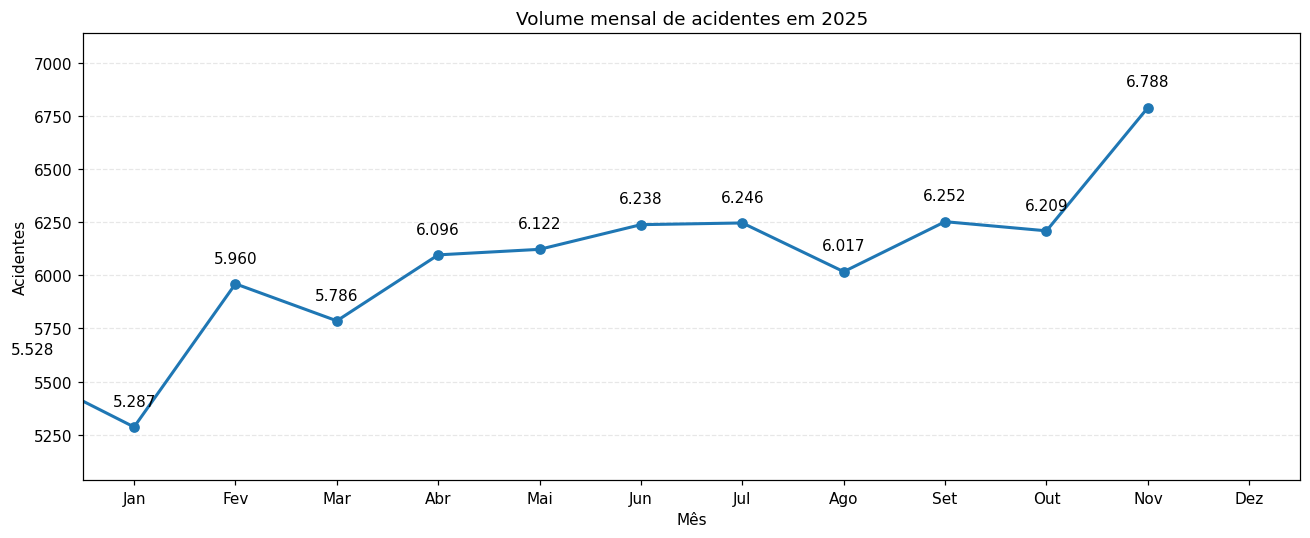

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    serie_mensal.index,
    serie_mensal["acidentes"],
    marker="o",
    linewidth=2
)

# Valores em cada ponto
for mes, valor in serie_mensal["acidentes"].items():
    plt.text(
        mes,
        valor + 100,
        f"{valor:,}".replace(",", "."),
        ha="center"
    )

plt.title("Volume mensal de acidentes em 2025")
plt.xlabel("Mês")
plt.ylabel("Acidentes")

plt.xticks(
    range(1, 13),
    ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
     "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
)

# Limites ajustados aos valores observados
minimo = serie_mensal["acidentes"].min()
maximo = serie_mensal["acidentes"].max()

plt.ylim(minimo - 250, maximo + 350)
plt.xlim(0.5, 12.5)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

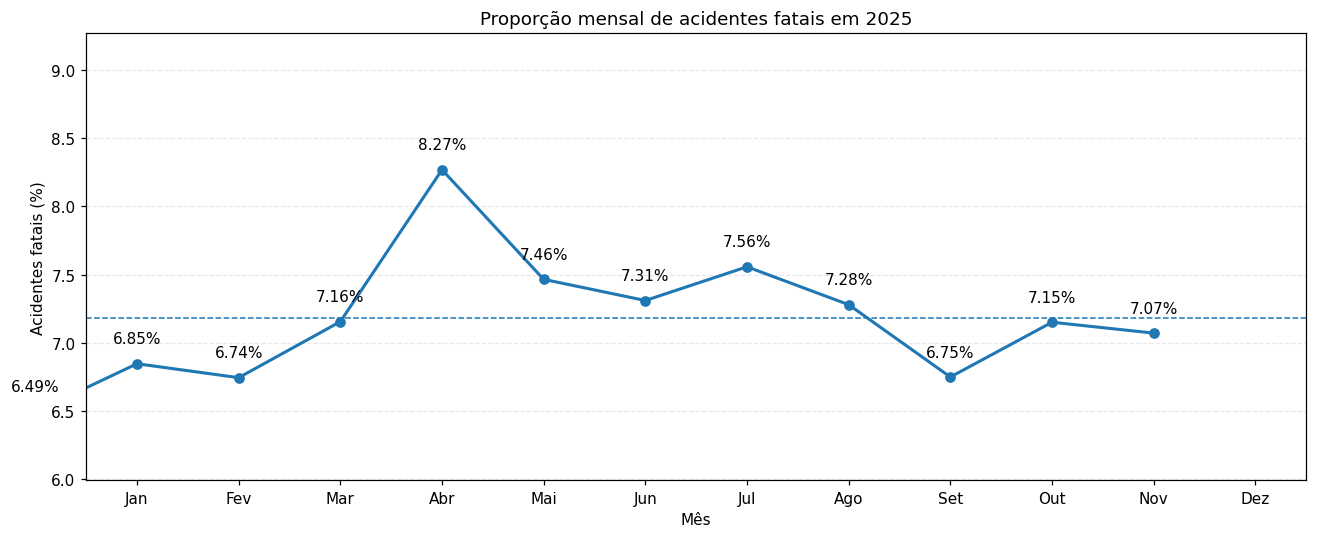

In [35]:
# Proporção mensal de acidentes fatais
# Compara cada mês com a proporção global de 7,18%

plt.figure(figsize=(12, 5))

plt.plot(
    serie_mensal.index,
    serie_mensal["pct_fatal"] * 100,
    marker="o",
    linewidth=2
)

# Linha da proporção global
plt.axhline(
    7.18,
    linestyle="--",
    linewidth=1
)

# Valores em cada ponto
for mes, valor in serie_mensal["pct_fatal"].items():
    plt.text(
        mes,
        valor * 100 + 0.15,
        f"{valor:.2%}",
        ha="center"
    )

plt.title("Proporção mensal de acidentes fatais em 2025")
plt.xlabel("Mês")
plt.ylabel("Acidentes fatais (%)")

plt.xticks(
    range(1, 13),
    ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
     "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
)

plt.xlim(0.5, 12.5)

# Reserva espaço para os rótulos acima do maior ponto
maior_valor = (serie_mensal["pct_fatal"] * 100).max()
menor_valor = (serie_mensal["pct_fatal"] * 100).min()

plt.ylim(
    max(0, menor_valor - 0.5),
    maior_valor + 1
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Ranking por dia da semana, respeitando a ordem lógica (segunda a domingo)
# em vez da ordem alfabética padrão do groupby
DIA_SEMANA_ORDEM = ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira",
                     "sexta-feira", "sábado", "domingo"]

rank_dia_semana = df.groupby("dia_semana", observed=True).agg(
    acidentes=("id", "count"),
    fatais=("acidente_fatal", "sum")
).reindex(DIA_SEMANA_ORDEM)

rank_dia_semana["pct_fatal"] = (
    rank_dia_semana["fatais"] / rank_dia_semana["acidentes"]
)

# Formata pct_fatal como percentual
rank_dia_semana["pct_fatal"] = rank_dia_semana["pct_fatal"].map(
    lambda x: f"{x:.2%}"
)

print("Acidentes por dia da semana:")
rank_dia_semana

Acidentes por dia da semana:


,acidentes,fatais,pct_fatal
dia_semana,,,
segunda-feira,10285,655,6.37%
terça-feira,9062,586,6.47%
quarta-feira,9556,608,6.36%
quinta-feira,9405,625,6.65%
sexta-feira,11197,766,6.84%
sábado,11554,953,8.25%
domingo,11470,1017,8.87%


In [37]:
# Criação da série por hora do dia — quando, ao longo das 24h, os acidentes e a
# proporção de acidentes fatais se concentram
serie_hora = df.groupby("hora", observed=True).agg(
    acidentes=("id", "count"),
    fatais=("acidente_fatal", "sum")
)

serie_hora["pct_fatal"] = (
    serie_hora["fatais"] / serie_hora["acidentes"]
)

# Formata pct_fatal como percentual
serie_hora["pct_fatal"] = serie_hora["pct_fatal"].map(
    lambda x: f"{x:.2%}"
)

serie_hora

,acidentes,fatais,pct_fatal
hora,,,
0,1508,166,11.01%
1,1291,130,10.07%
2,1160,143,12.33%
3,1263,173,13.70%
4,1595,207,12.98%
5,2090,259,12.39%
6,3169,242,7.64%
7,4583,174,3.80%
8,3765,155,4.12%


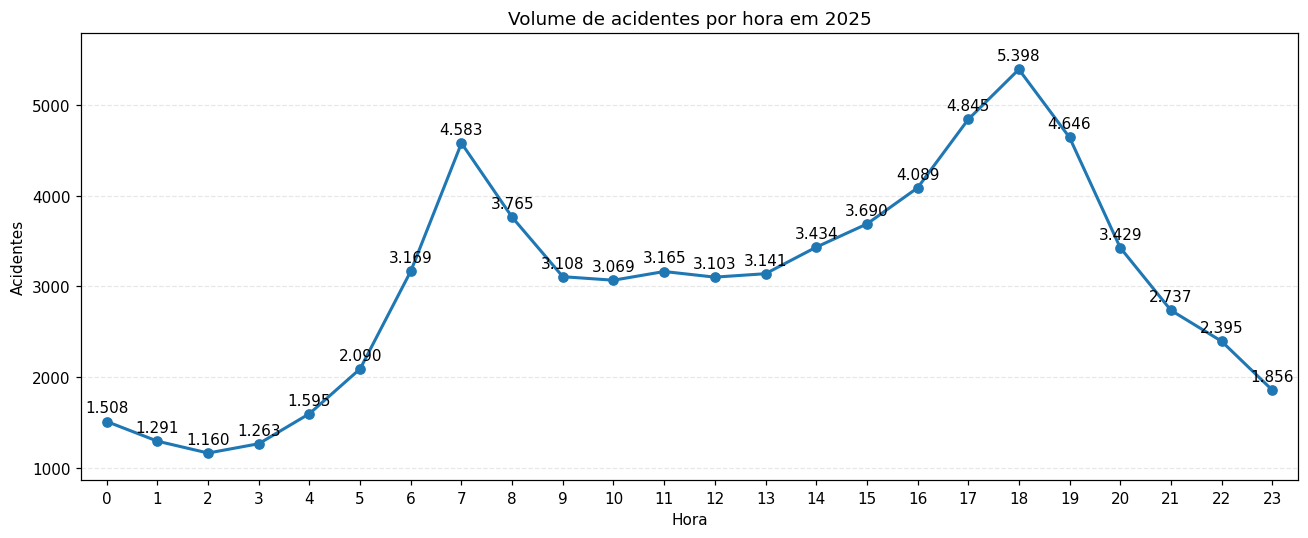

In [38]:
# Volume de acidentes por hora em 2025

plt.figure(figsize=(12, 5))

plt.plot(
    serie_hora.index,
    serie_hora["acidentes"],
    marker="o",
    linewidth=2
)

# Valores em cada ponto
for hora, valor in serie_hora["acidentes"].items():
    plt.text(
        hora,
        valor + 100,
        f"{valor:,}".replace(",", "."),
        ha="center"
    )

plt.title("Volume de acidentes por hora em 2025")
plt.xlabel("Hora")
plt.ylabel("Acidentes")

plt.xticks(range(24))

# Limites ajustados aos valores observados
minimo = serie_hora["acidentes"].min()
maximo = serie_hora["acidentes"].max()

plt.ylim(minimo - 300, maximo + 400)
plt.xlim(-0.5, 23.5)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

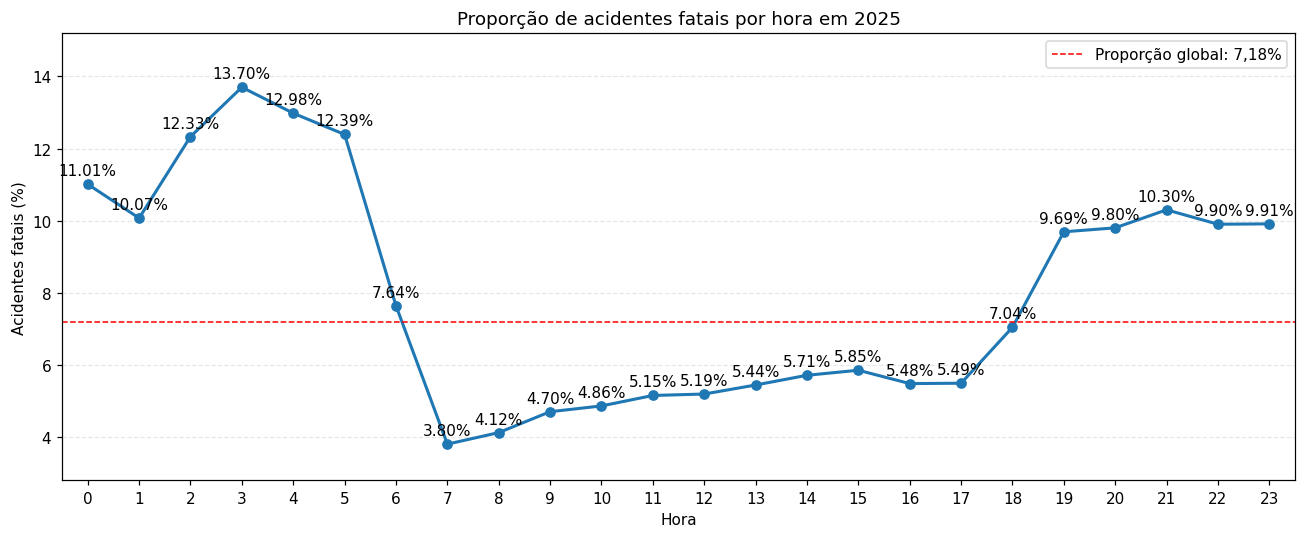

In [39]:
# Proporção de acidentes fatais por hora em 2025

plt.figure(figsize=(12, 5))

plt.plot(
    serie_hora.index,
    serie_hora["pct_fatal"].str.rstrip("%").astype(float),
    marker="o",
    linewidth=2
)

# Linha da proporção global
plt.axhline(
    7.18,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Proporção global: 7,18%"
)

# Valores em cada ponto
for hora, valor in serie_hora["pct_fatal"].items():
    valor_num = float(valor.rstrip("%"))
    plt.text(
        hora,
        valor_num + 0.25,
        valor,
        ha="center"
    )

plt.title("Proporção de acidentes fatais por hora em 2025")
plt.xlabel("Hora")
plt.ylabel("Acidentes fatais (%)")

plt.xticks(range(24))

# Limites ajustados aos valores observados
valores = serie_hora["pct_fatal"].str.rstrip("%").astype(float)
menor_valor = valores.min()
maior_valor = valores.max()

plt.ylim(
    max(0, menor_valor - 1),
    maior_valor + 1.5
)

plt.xlim(-0.5, 23.5)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 5. Análise bivariada — o que mais se associa ao indicador-alvo

Vamos cruzar as variáveis com acidente_fatal, observando volume, proporção de acidentes fatais e, quando pertinente, a distância em relação à referência global de 7,18%. Para categorias com poucos registros, aplicaremos um volume mínimo, evitando interpretações de percentuais instáveis.

In [40]:
# Definição da função de análise bivariada
# Função central do roteiro: recebe uma variável explicativa (ex.: "causa_acidente") e cruza
# com a variável-alvo (acidente_fatal), calculando volume, quantidade de acidentes fatais
# e o percentual de letalidade por categoria
def analise_bivariada(var, min_acidentes=30):
    tab = df.groupby(var, observed=True).agg(
        acidentes=("id", "count"),                 # total de acidentes na categoria
        fatais=("acidente_fatal", "sum"),           # total de acidentes fatais na categoria
        mortos=("mortos", "sum"),                    # total de mortos na categoria
    )
    tab["pct_fatal"] = tab["fatais"] / tab["acidentes"]  # proporção condicional de letalidade
    tab = tab[tab["acidentes"] >= min_acidentes]          # filtro de volume mínimo (evita categorias irrisórias)
    return tab.sort_values("pct_fatal", ascending=False)  # ordena da maior para a menor letalidade

# Exibição da taxa global, para servir de referência de comparação em todas as tabelas abaixo
print(f"Taxa global de referência: {pct_fatais:.1%}\n")

Taxa global de referência: 7.2%



### 5.1 Variáveis temporais


*   5.1.1 Fase do dia × indicador-alvo

*   5.1.2 Dia da semana × indicador-alvo

*   5.1.3 Hora × indicador-alvo




In [41]:
# Laço de repetição que aplica a função de análise bivariada às três variáveis temporais
# Repete a mesma lógica de forma padronizada para fase do dia, dia da semana e hora
for var, min_n in [("fase_dia", 100), ("dia_semana", 100), ("hora", 100)]:
    print(f"=== {var} x acidente_fatal (mínimo {min_n} acidentes) ===")
    display(analise_bivariada(var, min_n))
    print()

=== fase_dia x acidente_fatal (mínimo 100 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
fase_dia,,,,
Amanhecer,3447,386,472,0.11
Plena Noite,24781,2522,2892,0.10
Anoitecer,3926,253,288,0.06
Pleno dia,40375,2049,2391,0.05



=== dia_semana x acidente_fatal (mínimo 100 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
dia_semana,,,,
domingo,11470,1017,1183,0.09
sábado,11554,953,1120,0.08
sexta-feira,11197,766,907,0.07
quinta-feira,9405,625,694,0.07
terça-feira,9062,586,681,0.06
segunda-feira,10285,655,747,0.06
quarta-feira,9556,608,711,0.06



=== hora x acidente_fatal (mínimo 100 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
hora,,,,
3,1263,173,208,0.14
4,1595,207,249,0.13
5,2090,259,307,0.12
2,1160,143,163,0.12
0,1508,166,192,0.11
21,2737,282,327,0.10
1,1291,130,151,0.10
23,1856,184,204,0.10
22,2395,237,258,0.10


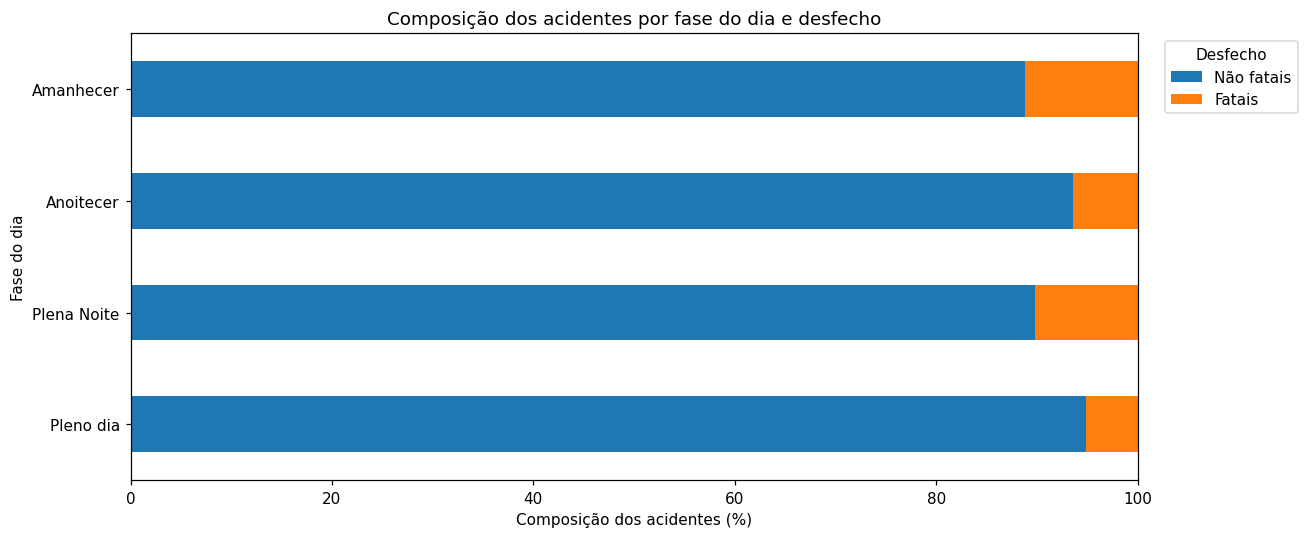

In [42]:
# Análise bivariada por fase do dia
grafico_fase = analise_bivariada("fase_dia", 30).copy()

# Calcula a quantidade de acidentes não fatais
grafico_fase["nao_fatais"] = (
    grafico_fase["acidentes"] - grafico_fase["fatais"]
)

# Calcula a proporção de acidentes não fatais e fatais dentro de cada fase
grafico_fase["pct_nao_fatais"] = (
    grafico_fase["nao_fatais"] / grafico_fase["acidentes"] * 100
)

grafico_fase["pct_fatais"] = (
    grafico_fase["fatais"] / grafico_fase["acidentes"] * 100
)

# Define a ordem das fases
grafico_fase = grafico_fase.reindex(
    ["Pleno dia", "Plena Noite", "Anoitecer", "Amanhecer"]
)

# Gráfico de barras empilhadas 100%
ax = grafico_fase[
    ["pct_nao_fatais", "pct_fatais"]
].plot(
    kind="barh",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Composição dos acidentes por fase do dia e desfecho")
plt.xlabel("Composição dos acidentes (%)")
plt.ylabel("Fase do dia")

plt.xlim(0, 100)

plt.legend(
    ["Não fatais", "Fatais"],
    title="Desfecho",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

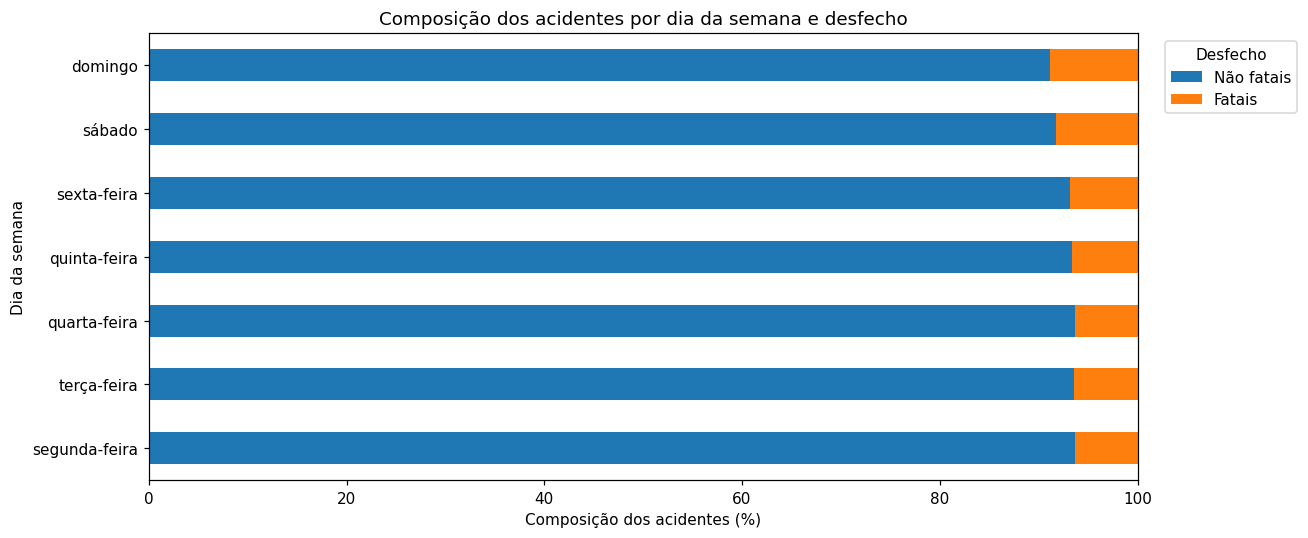

In [43]:
# Análise bivariada por dia da semana
grafico_dia = analise_bivariada("dia_semana", 30).copy()

# Calcula a quantidade de acidentes não fatais
grafico_dia["nao_fatais"] = (
    grafico_dia["acidentes"] - grafico_dia["fatais"]
)

# Calcula a composição percentual de cada dia
grafico_dia["pct_nao_fatais"] = (
    grafico_dia["nao_fatais"] / grafico_dia["acidentes"] * 100
)

grafico_dia["pct_fatais"] = (
    grafico_dia["fatais"] / grafico_dia["acidentes"] * 100
)

# Define a ordem dos dias da semana
grafico_dia = grafico_dia.reindex([
    "segunda-feira",
    "terça-feira",
    "quarta-feira",
    "quinta-feira",
    "sexta-feira",
    "sábado",
    "domingo"
])

# Gráfico de barras empilhadas 100%
ax = grafico_dia[
    ["pct_nao_fatais", "pct_fatais"]
].plot(
    kind="barh",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Composição dos acidentes por dia da semana e desfecho")
plt.xlabel("Composição dos acidentes (%)")
plt.ylabel("Dia da semana")

plt.xlim(0, 100)

plt.legend(
    ["Não fatais", "Fatais"],
    title="Desfecho",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

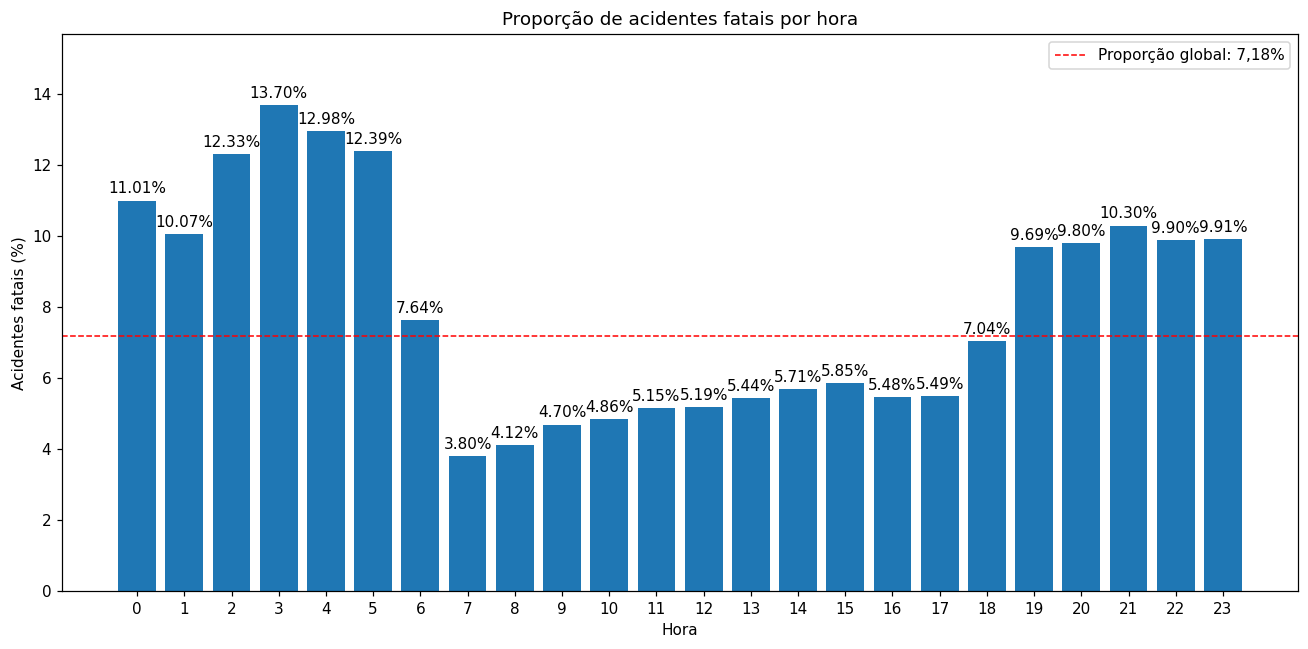

In [44]:
# Calcula a proporção de acidentes fatais por hora
grafico_hora = analise_bivariada("hora", 30).copy()

# Converte a proporção para percentual
grafico_hora["pct_fatal"] = grafico_hora["pct_fatal"] * 100

# Ordena as horas cronologicamente
grafico_hora = grafico_hora.sort_index()

# Cria o gráfico de barras verticais
plt.figure(figsize=(12, 6))

plt.bar(
    grafico_hora.index.astype(str),
    grafico_hora["pct_fatal"]
)

# Linha de referência da proporção global
plt.axhline(
    7.18,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Proporção global: 7,18%"
)

# Valores no topo de cada barra
for hora, valor in zip(
    grafico_hora.index,
    grafico_hora["pct_fatal"]
):
    plt.text(
        hora,
        valor + 0.2,
        f"{valor:.2f}%",
        ha="center"
    )

plt.title("Proporção de acidentes fatais por hora")
plt.xlabel("Hora")
plt.ylabel("Acidentes fatais (%)")

# Reserva espaço para os valores
plt.ylim(
    0,
    grafico_hora["pct_fatal"].max() + 2
)

plt.legend()

plt.tight_layout()
plt.show()

###5.2 Variáveis relacionadas às condições do acidente


*   5.2.1 Tipo de acidente × indicador-alvo

*   5.2.2 Classificação do acidente × indicador-alvo

*   5.2.3 Condição meteorológica × indicador-alvo

In [45]:
# Laço de repetição que aplica a função de análise bivariada às variáveis da seção 5.2
# Repete a mesma lógica de forma padronizada para tipo, classificação e condição meteorológica

for var, min_n in [
    ("tipo_acidente", 100),
    ("classificacao_acidente", 30),
    ("condicao_metereologica", 30)
]:
    resultado = analise_bivariada(var, min_n).copy()

    # Converte pct_fatal para percentual
    resultado["pct_fatal"] = resultado["pct_fatal"].map(lambda x: f"{x:.2%}")

    print(f"=== {var} x acidente_fatal (mínimo {min_n} acidentes) ===")
    display(resultado)
    print()

=== tipo_acidente x acidente_fatal (mínimo 100 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
tipo_acidente,,,,
Atropelamento de Pedestre,3057,902,919,29.51%
Colisão frontal,4739,1396,1863,29.46%
Colisão lateral sentido oposto,2152,212,255,9.85%
Eventos atípicos,287,23,24,8.01%
Atropelamento de Animal,1133,68,74,6.00%
Saída de leito carroçável,10209,605,700,5.93%
Colisão com objeto,5109,297,323,5.81%
Capotamento,1373,63,74,4.59%
Colisão transversal,9306,427,481,4.59%



=== classificacao_acidente x acidente_fatal (mínimo 30 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
classificacao_acidente,,,,
Com Vítimas Fatais,5209,5209,6042,100.00%
Com Vítimas Feridas,56181,0,0,0.00%
Sem Vítimas,11138,0,0,0.00%



=== condicao_metereologica x acidente_fatal (mínimo 30 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
condicao_metereologica,,,,
Nevoeiro/Neblina,553,60,74,10.85%
Ignorado,1000,99,115,9.90%
Vento,104,9,10,8.65%
Céu Claro,46375,3419,3948,7.37%
Nublado,11435,830,955,7.26%
Chuva,6438,402,480,6.24%
Garoa/Chuvisco,2422,144,175,5.95%
Sol,4201,247,286,5.88%


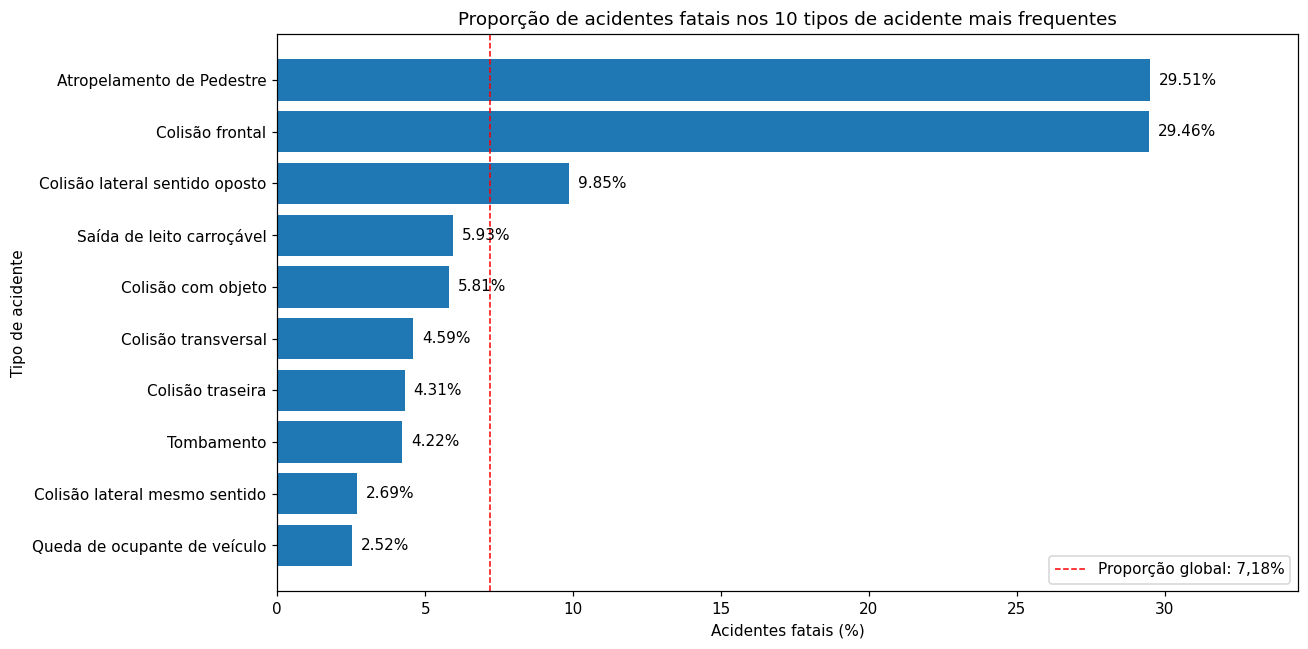

In [49]:
# Proporção de acidentes fatais nos 10 tipos de acidente mais frequentes

# Recalcula a análise bivariada sem transformar pct_fatal em texto
grafico_tipo = analise_bivariada(
    "tipo_acidente",
    100
).copy()

# Seleciona os 10 tipos com maior volume de acidentes
grafico_tipo = grafico_tipo.nlargest(
    10,
    "acidentes"
)

# Converte a proporção de acidentes fatais para percentual
grafico_tipo["pct_fatal"] = (
    grafico_tipo["pct_fatal"] * 100
)

# Ordena os 10 tipos pelo percentual para facilitar a leitura
grafico_tipo = grafico_tipo.sort_values(
    "pct_fatal"
)

# Cria o gráfico
plt.figure(figsize=(12, 6))

plt.barh(
    grafico_tipo.index,
    grafico_tipo["pct_fatal"]
)

# Linha de referência global
plt.axvline(
    7.18,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Proporção global: 7,18%"
)

# Valores no final das barras
for categoria, valor in zip(
    grafico_tipo.index,
    grafico_tipo["pct_fatal"]
):
    plt.text(
        valor + 0.3,
        categoria,
        f"{valor:.2f}%",
        va="center"
    )

plt.title(
    "Proporção de acidentes fatais nos 10 tipos de acidente mais frequentes"
)

plt.xlabel("Acidentes fatais (%)")
plt.ylabel("Tipo de acidente")

# Reserva espaço para os valores
plt.xlim(
    0,
    grafico_tipo["pct_fatal"].max() + 5
)

plt.legend()

plt.tight_layout()
plt.show()

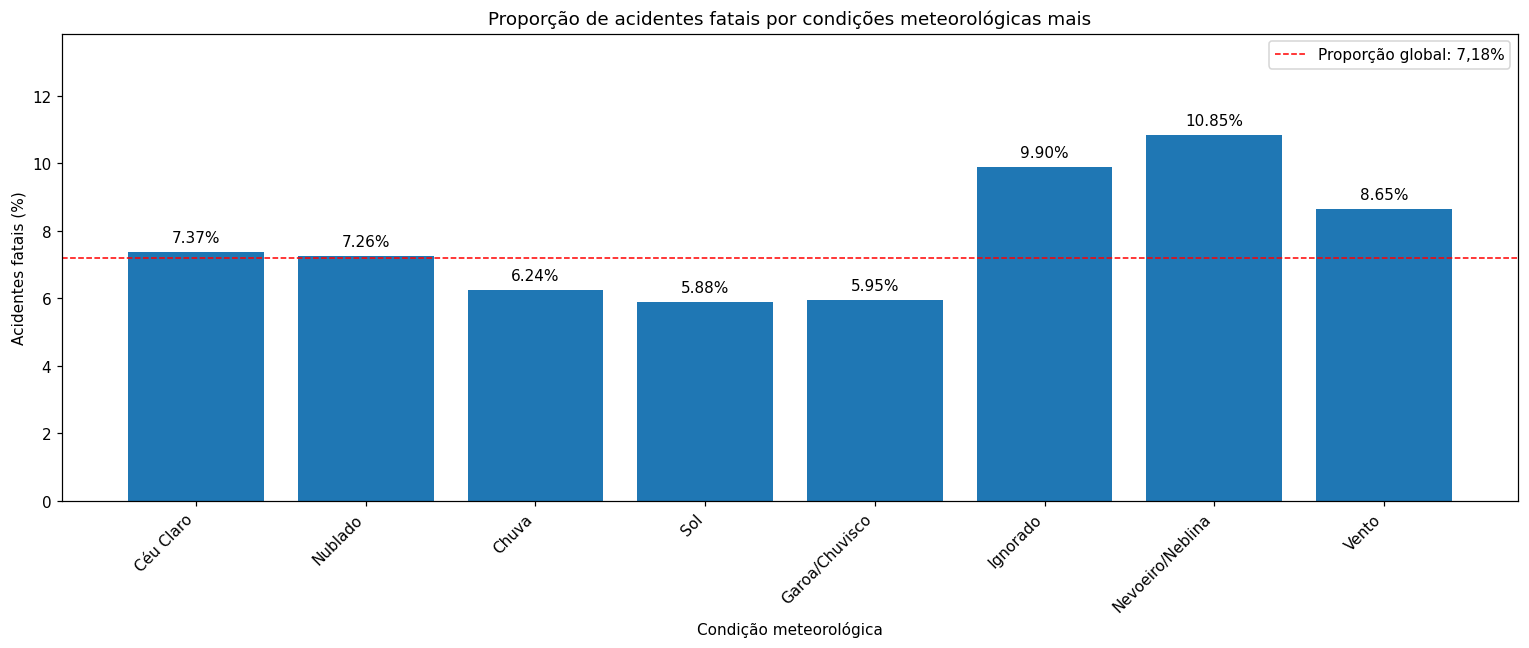

In [53]:
# Proporção de acidentes fatais nos 10 tipos de acidente mais frequentes

# Recalcula a análise bivariada
grafico_meteo = analise_bivariada(
    "condicao_metereologica",
    30
).copy()

# Seleciona as 10 condições meteorológicas com maior volume
grafico_meteo = grafico_meteo.nlargest(
    10,
    "acidentes"
)

# Converte a proporção para percentual
grafico_meteo["pct_fatal"] = (
    grafico_meteo["pct_fatal"] * 100
)

# Cria o gráfico de barras verticais
plt.figure(figsize=(14, 6))

plt.bar(
    grafico_meteo.index,
    grafico_meteo["pct_fatal"]
)

# Linha de referência global
plt.axhline(
    7.18,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Proporção global: 7,18%"
)

# Valores no topo das barras
for categoria, valor in zip(
    grafico_meteo.index,
    grafico_meteo["pct_fatal"]
):
    plt.text(
        categoria,
        valor + 0.3,
        f"{valor:.2f}%",
        ha="center"
    )

plt.title(
    "Proporção de acidentes fatais por condições meteorológicas mais"
)

plt.xlabel("Condição meteorológica")
plt.ylabel("Acidentes fatais (%)")

# Reserva espaço para os valores
plt.ylim(
    0,
    grafico_meteo["pct_fatal"].max() + 3
)

plt.xticks(rotation=45, ha="right")

plt.legend()

plt.tight_layout()
plt.show()

### 5.3 Variáveis contextuais



*   5.3.1 Uso do solo × indicador-alvo
*   5.3.2 Condição meteorológica × fase do dia
*   5.3.3 Dia da semana × fase do dia



In [57]:
# Análise de uso do solo × indicador-alvo
resultado = analise_bivariada("uso_solo", 30).copy()

# Converte a proporção de acidentes fatais para percentual
resultado["pct_fatal"] = resultado["pct_fatal"].map(
    lambda x: f"{x:.2%}"
)

print("=== uso_solo x acidente_fatal (mínimo 30 acidentes) ===")
display(resultado)

=== uso_solo x acidente_fatal (mínimo 30 acidentes) ===


,acidentes,fatais,mortos,pct_fatal
uso_solo,,,,
Não,41444,3774,4509,9.11%
Sim,31085,1436,1534,4.62%


In [58]:
# Laço de repetição que aplica a análise aos cruzamentos contextuais de 5.3
# Mostra como a proporção de acidentes fatais varia quando os fatores são combinados

for var1, var2, min_n in [
    ("condicao_metereologica", "fase_dia", 100),
    ("dia_semana", "fase_dia", 100)
]:
    resultado = df.groupby(
        [var1, var2],
        observed=True
    ).agg(
        acidentes=("id", "count"),
        fatais=("acidente_fatal", "sum"),
        mortos=("mortos", "sum")
    )

    # Calcula a proporção de acidentes fatais em cada combinação
    resultado["pct_fatal"] = (
        resultado["fatais"] / resultado["acidentes"]
    )

    # Mantém apenas combinações com volume mínimo de acidentes
    resultado = resultado[
        resultado["acidentes"] >= min_n
    ]

    # Ordena da maior para a menor proporção de acidentes fatais
    resultado = resultado.sort_values(
        "pct_fatal",
        ascending=False
    )

    # Formata a proporção como percentual
    resultado["pct_fatal"] = resultado["pct_fatal"].map(
        lambda x: f"{x:.2%}"
    )

    print(
        f"=== {var1} x {var2} "
        f"(mínimo {min_n} acidentes) ==="
    )

    display(resultado)
    print()

=== condicao_metereologica x fase_dia (mínimo 100 acidentes) ===


acidentes  fatais  mortos pct_fatal
condicao_metereologica fase_dia                                        
Nevoeiro/Neblina       Plena Noite        245      37      46    15.10%
Céu Claro              Amanhecer         2010     241     290    11.99%
Nevoeiro/Neblina       Amanhecer          169      19      24    11.24%
Ignorado               Plena Noite        670      73      87    10.90%
Céu Claro              Plena Noite      15909    1669    1900    10.49%
Nublado                Plena Noite       4556     471     540    10.34%
                       Amanhecer          606      62      76    10.23%
Chuva                  Amanhecer          330      30      34     9.09%
Garoa/Chuvisco         Plena Noite       1037      84     104     8.10%
Chuva                  Plena Noite       2282     181     207     7.93%
Garoa/Chuvisco         Amanhecer          168      12      13     7.14%
Céu Claro              Anoitecer         2515     173     200     6.88%
Sol                    Pleno dia         4089     234     261     5.72%
Chuva                  Anoitecer          411      23      26     5.60%
Nublado                Anoitecer          705      39      42     5.53%
Céu Claro              Pleno dia        25941    1336    1558     5.15%
Ignorado               Pleno dia          160       8       8     5.00%
Chuva                  Pleno dia         3415     168     213     4.92%
Nublado                Pleno dia         5568     258     297     4.63%
Garoa/Chuvisco         Anoitecer          159       7       8     4.40%
                       Pleno dia         1058      41      50     3.88%
Nevoeiro/Neblina       Pleno dia          131       2       2     1.53%


=== dia_semana x fase_dia (mínimo 100 acidentes) ===


,,acidentes,fatais,mortos,pct_fatal
dia_semana,fase_dia,,,,
quarta-feira,Amanhecer,389,54,71,13.88%
segunda-feira,Amanhecer,518,62,79,11.97%
domingo,Amanhecer,631,73,85,11.57%
sábado,Plena Noite,4710,530,620,11.25%
domingo,Plena Noite,4832,540,617,11.18%
sexta-feira,Amanhecer,493,55,70,11.16%
sábado,Amanhecer,602,65,76,10.80%
quinta-feira,Amanhecer,422,45,54,10.66%
sexta-feira,Plena Noite,3829,372,446,9.72%


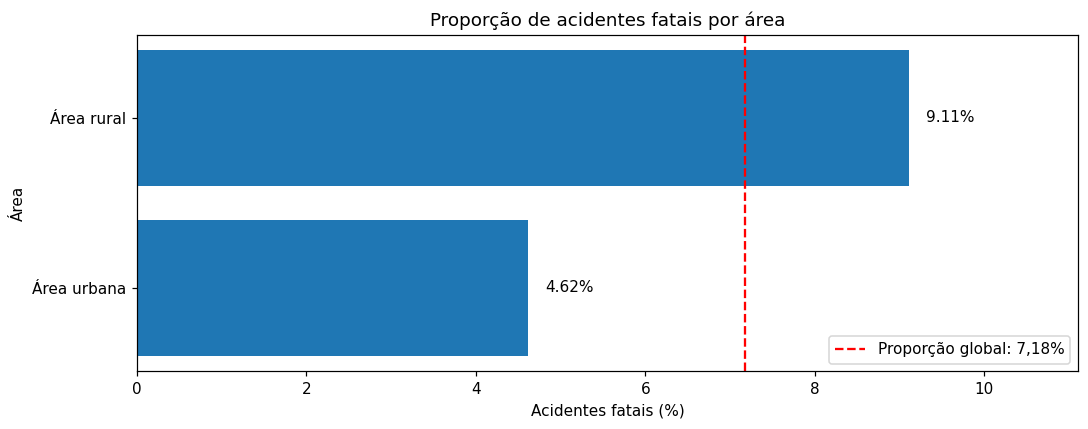

In [55]:
# Análise bivariada por uso do solo
grafico_uso = analise_bivariada("uso_solo", 30).copy()

# Converte a proporção de acidentes fatais para percentual
grafico_uso["pct_fatal"] = grafico_uso["pct_fatal"] * 100

# Renomeia as categorias para facilitar a interpretação
grafico_uso = grafico_uso.rename(
    index={
        "Sim": "Área urbana",
        "Não": "Área rural"
    }
)

# Ordena pelo percentual de acidentes fatais
grafico_uso = grafico_uso.sort_values("pct_fatal")

# Cria o gráfico de barras horizontais
plt.figure(figsize=(10, 4))

plt.barh(
    grafico_uso.index,
    grafico_uso["pct_fatal"]
)

# Linha de referência global
plt.axvline(
    7.18,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Proporção global: 7,18%"
)

# Valores no final das barras
for categoria, valor in zip(
    grafico_uso.index,
    grafico_uso["pct_fatal"]
):
    plt.text(
        valor + 0.2,
        categoria,
        f"{valor:.2f}%",
        va="center"
    )

plt.title("Proporção de acidentes fatais por área")
plt.xlabel("Acidentes fatais (%)")
plt.ylabel("Área")

plt.xlim(
    0,
    grafico_uso["pct_fatal"].max() + 2
)

plt.legend()

plt.tight_layout()
plt.show()

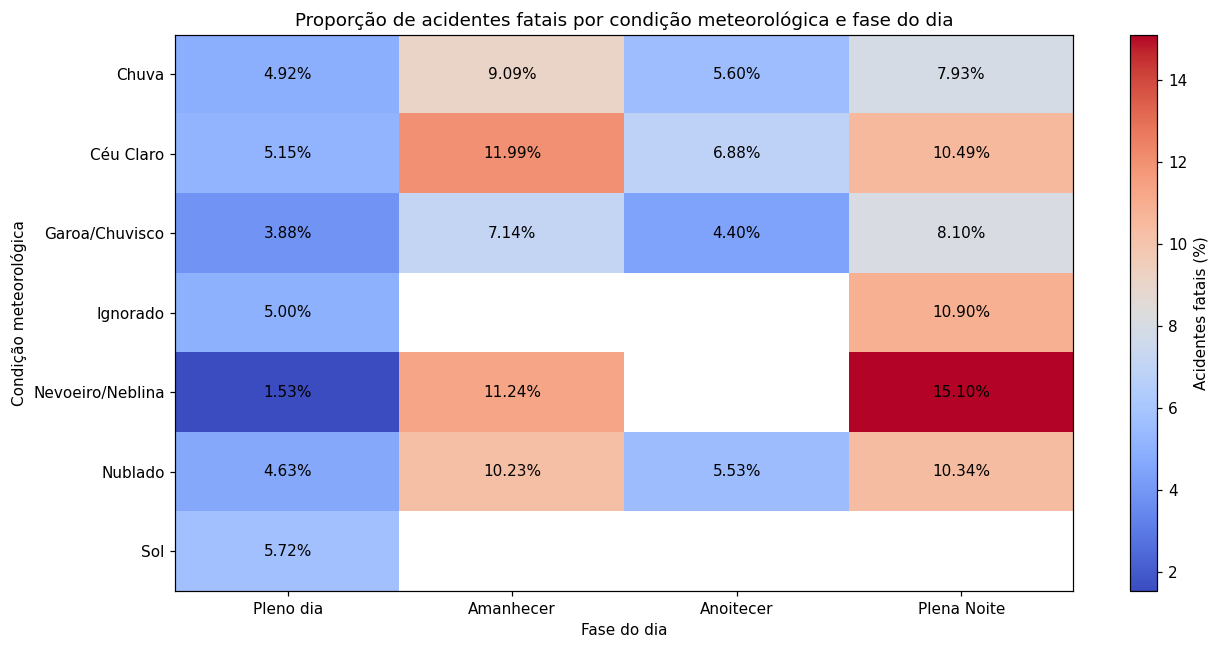

In [60]:
# Cria o heatmap com escala de cores do frio ao quente
plt.figure(figsize=(12, 6))

plt.imshow(
    matriz,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(
    label="Acidentes fatais (%)"
)

plt.xticks(
    range(len(matriz.columns)),
    matriz.columns
)

plt.yticks(
    range(len(matriz.index)),
    matriz.index
)

# Valores dentro das células
for i in range(len(matriz.index)):
    for j in range(len(matriz.columns)):
        valor = matriz.iloc[i, j]

        if pd.notna(valor):
            plt.text(
                j,
                i,
                f"{valor:.2f}%",
                ha="center",
                va="center"
            )

plt.title(
    "Proporção de acidentes fatais por condição meteorológica e fase do dia"
)

plt.xlabel("Fase do dia")
plt.ylabel("Condição meteorológica")

plt.tight_layout()
plt.show()

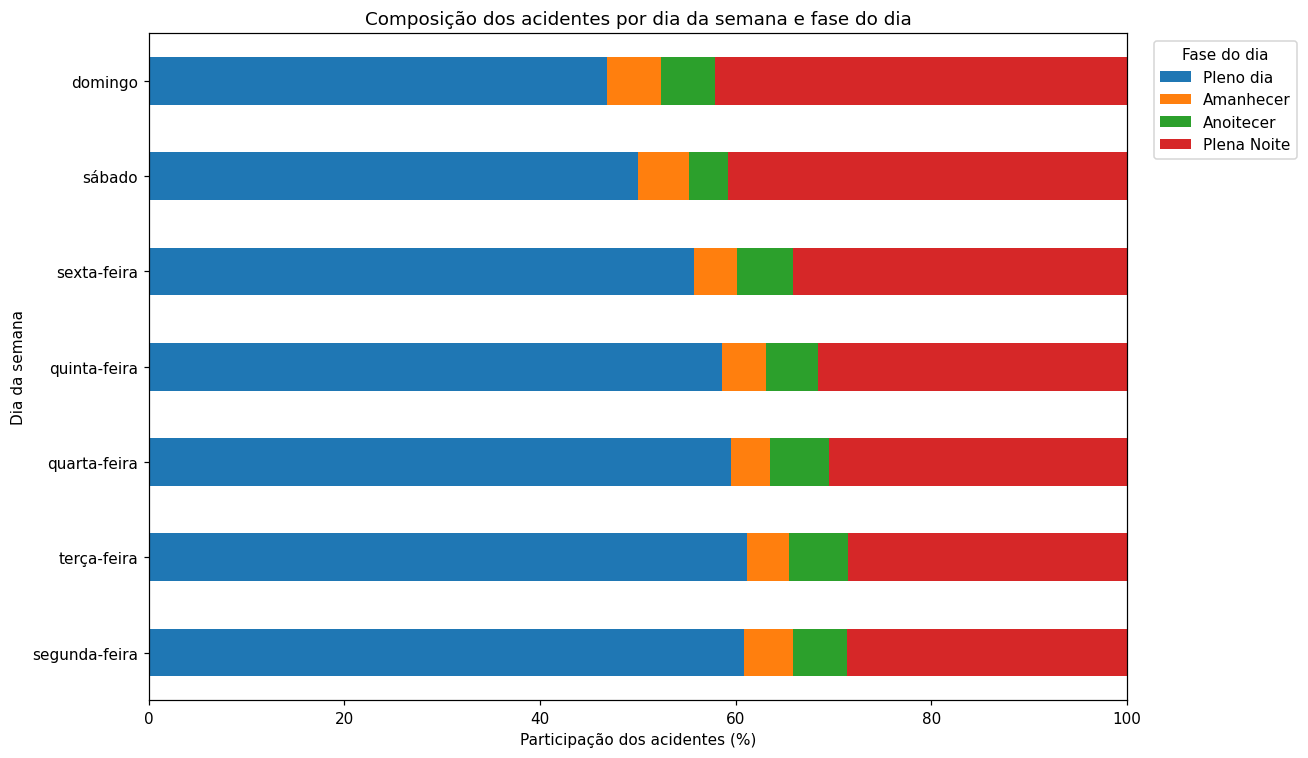

In [64]:
# Cruzamento: dia da semana × fase do dia
grafico_dia_fase = df.groupby(
    ["dia_semana", "fase_dia"],
    observed=True
).agg(
    acidentes=("id", "count")
)

# Calcula a participação de cada fase dentro de cada dia da semana
grafico_dia_fase["pct_fase"] = (
    grafico_dia_fase["acidentes"] /
    grafico_dia_fase.groupby(level=0)["acidentes"].transform("sum") *
    100
)

# Transforma as fases em colunas
tabela_grafico = grafico_dia_fase["pct_fase"].unstack()

# Define a ordem dos dias
tabela_grafico = tabela_grafico.reindex([
    "segunda-feira",
    "terça-feira",
    "quarta-feira",
    "quinta-feira",
    "sexta-feira",
    "sábado",
    "domingo"
])

# Define a ordem das fases
tabela_grafico = tabela_grafico[
    ["Pleno dia", "Amanhecer", "Anoitecer", "Plena Noite"]
]

# Gráfico de barras 100% empilhadas
ax = tabela_grafico.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

plt.title(
    "Composição dos acidentes por dia da semana e fase do dia"
)

plt.xlabel("Participação dos acidentes (%)")
plt.ylabel("Dia da semana")

plt.xlim(0, 100)

plt.legend(
    title="Fase do dia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

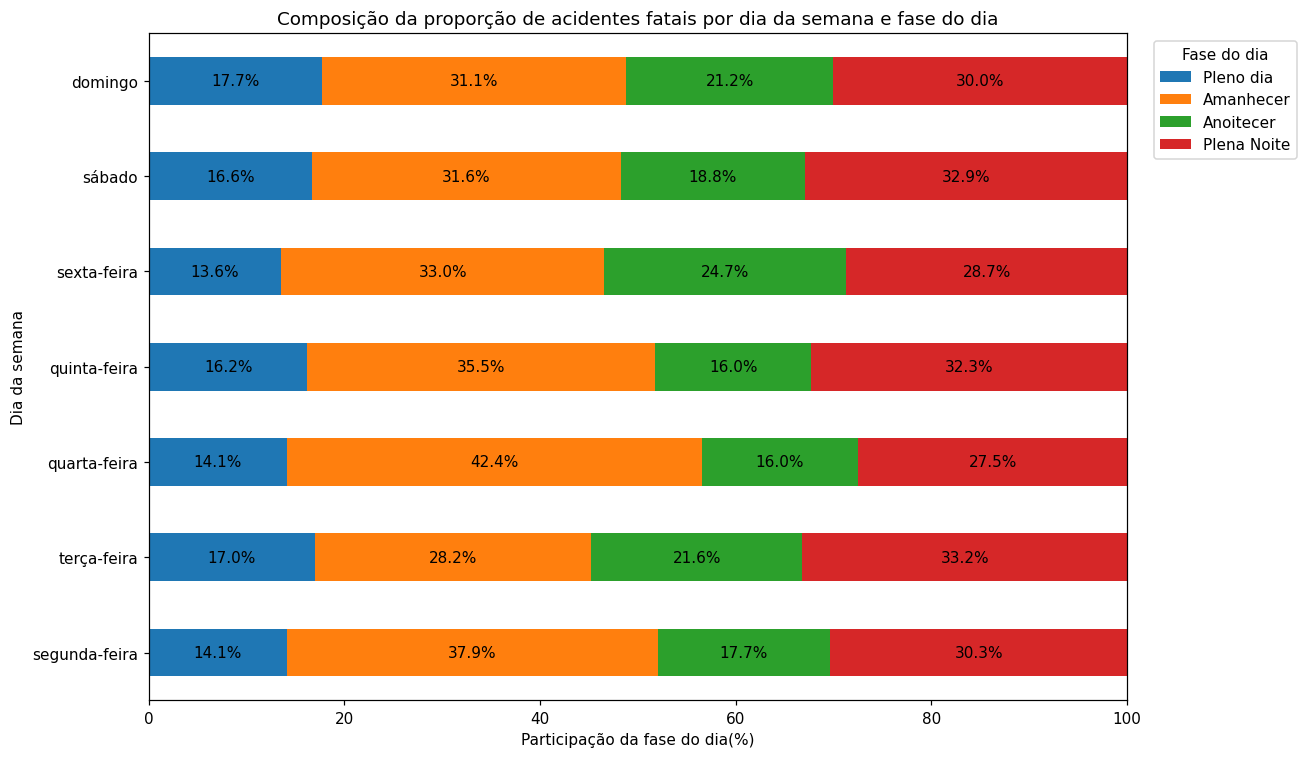

In [82]:
# Cruzamento: dia da semana × fase do dia
grafico_dia_fase = df.groupby(
    ["dia_semana", "fase_dia"],
    observed=True
).agg(
    acidentes=("id", "count"),
    fatais=("acidente_fatal", "sum")
)

# Calcula a proporção de acidentes fatais em cada combinação
grafico_dia_fase["pct_fatal"] = (
    grafico_dia_fase["fatais"] /
    grafico_dia_fase["acidentes"] *
    100
)

# Mantém apenas combinações com pelo menos 100 acidentes
grafico_dia_fase = grafico_dia_fase[
    grafico_dia_fase["acidentes"] >= 100
]

# Transforma as fases em colunas
tabela_grafico = grafico_dia_fase["pct_fatal"].unstack()

# Define a ordem dos dias
tabela_grafico = tabela_grafico.reindex([
    "segunda-feira",
    "terça-feira",
    "quarta-feira",
    "quinta-feira",
    "sexta-feira",
    "sábado",
    "domingo"
])

# Define a ordem das fases
tabela_grafico = tabela_grafico[
    ["Pleno dia", "Amanhecer", "Anoitecer", "Plena Noite"]
]

# Normaliza as proporções para que cada dia some 100%
tabela_grafico = tabela_grafico.div(
    tabela_grafico.sum(axis=1),
    axis=0
) * 100

# Cria o gráfico de barras horizontais 100% empilhadas
ax = tabela_grafico.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

# Coloca os percentuais dentro de cada segmento
for i, dia in enumerate(tabela_grafico.index):
    acumulado = 0

    for fase in tabela_grafico.columns:
        valor = tabela_grafico.loc[dia, fase]

        if pd.notna(valor) and valor > 4:
            plt.text(
                acumulado + valor / 2,
                i,
                f"{valor:.1f}%",
                ha="center",
                va="center"
            )

        acumulado += 0 if pd.isna(valor) else valor

plt.title(
    "Composição da proporção de acidentes fatais por dia da semana e fase do dia"
)

plt.xlabel("Participação da fase do dia(%)")
plt.ylabel("Dia da semana")

plt.xlim(0, 100)

plt.legend(
    title="Fase do dia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

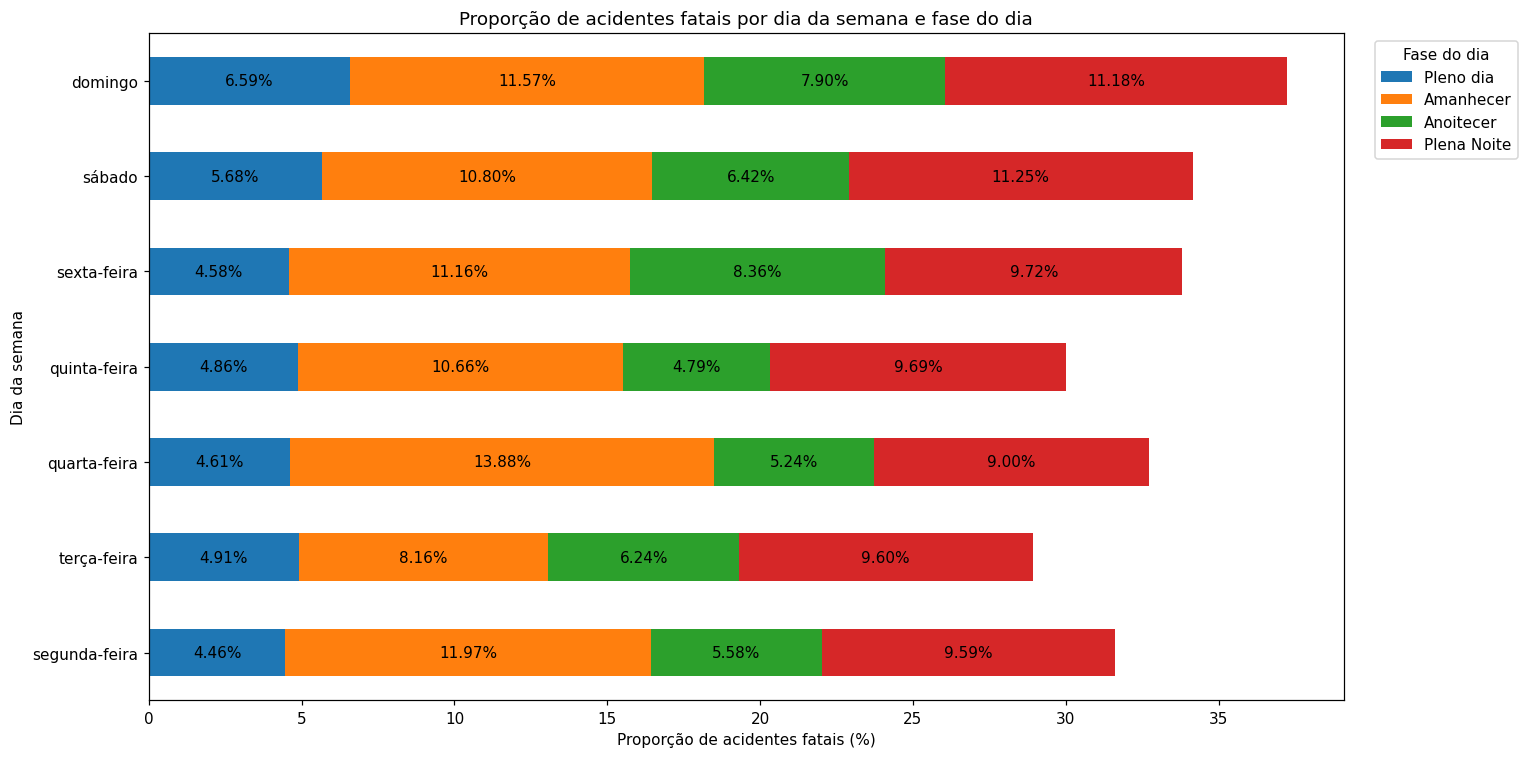

In [73]:
# Cruzamento: dia da semana × fase do dia
grafico_dia_fase = df.groupby(
    ["dia_semana", "fase_dia"],
    observed=True
).agg(
    acidentes=("id", "count"),
    fatais=("acidente_fatal", "sum")
)

# Calcula a taxa original de acidentes fatais em cada combinação
grafico_dia_fase["pct_fatal"] = (
    grafico_dia_fase["fatais"] /
    grafico_dia_fase["acidentes"] *
    100
)

# Mantém apenas combinações com pelo menos 100 acidentes
grafico_dia_fase = grafico_dia_fase[
    grafico_dia_fase["acidentes"] >= 100
]

# Transforma as fases em colunas
tabela_grafico = grafico_dia_fase["pct_fatal"].unstack()

# Define a ordem dos dias
tabela_grafico = tabela_grafico.reindex([
    "segunda-feira",
    "terça-feira",
    "quarta-feira",
    "quinta-feira",
    "sexta-feira",
    "sábado",
    "domingo"
])

# Define a ordem das fases
tabela_grafico = tabela_grafico[
    ["Pleno dia", "Amanhecer", "Anoitecer", "Plena Noite"]
]

# Cria as barras horizontais empilhadas
ax = tabela_grafico.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 7)
)

# Coloca a taxa original dentro de cada segmento
for i, dia in enumerate(tabela_grafico.index):
    acumulado = 0

    for fase in tabela_grafico.columns:
        valor = tabela_grafico.loc[dia, fase]

        if pd.notna(valor):
            # Só mostra o valor quando o segmento tiver espaço suficiente
            if valor >= 1.5:
                plt.text(
                    acumulado + valor / 2,
                    i,
                    f"{valor:.2f}%",
                    ha="center",
                    va="center"
                )

            acumulado += valor

plt.title(
    "Proporção de acidentes fatais por dia da semana e fase do dia"
)

plt.xlabel("Proporção de acidentes fatais (%)")
plt.ylabel("Dia da semana")

plt.legend(
    title="Fase do dia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

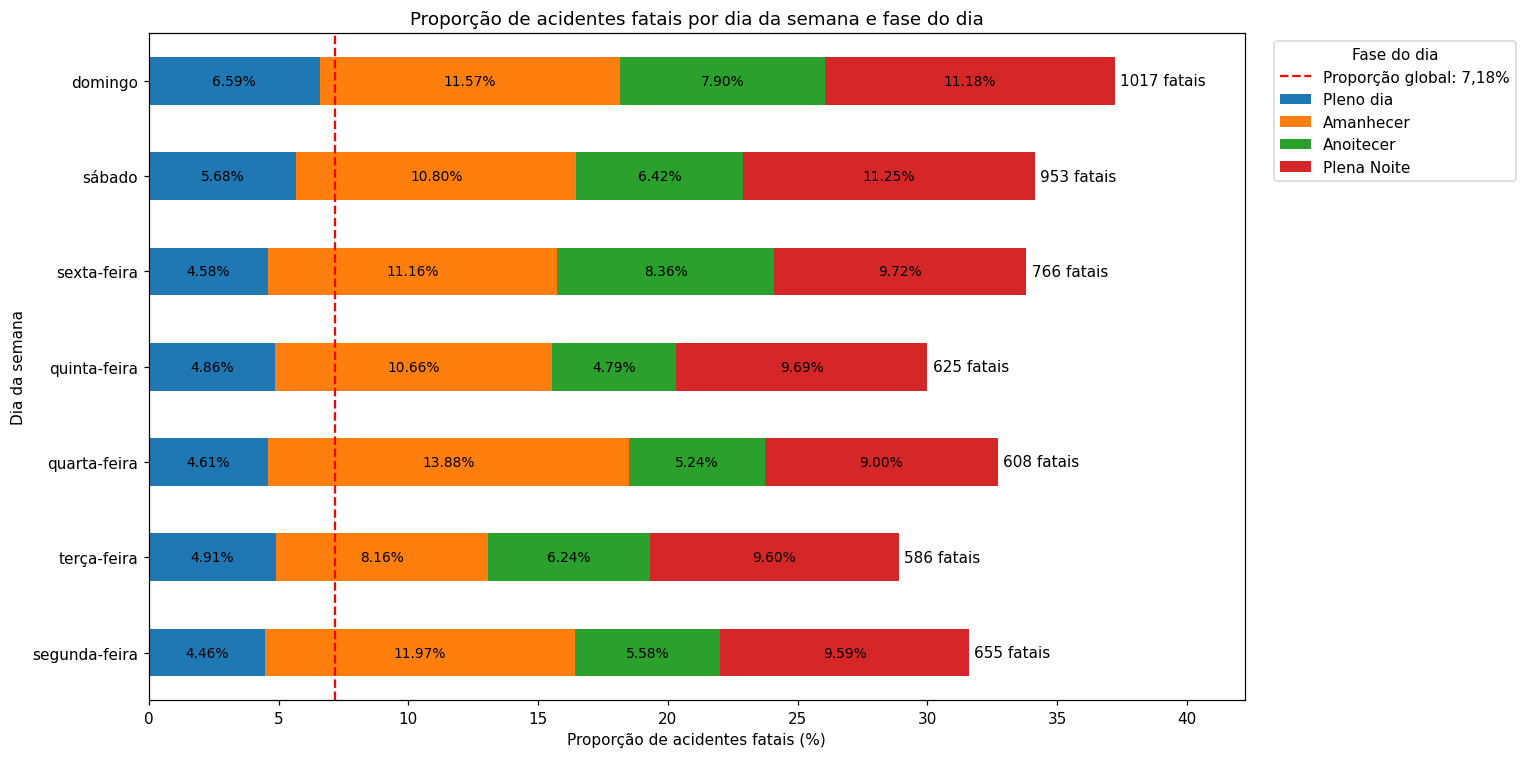

In [81]:
# Cruzamento: dia da semana × fase do dia
grafico_dia_fase = df.groupby(
    ["dia_semana", "fase_dia"],
    observed=True
).agg(
    acidentes=("id", "count"),
    fatais=("acidente_fatal", "sum")
)

# Calcula a taxa original de acidentes fatais em cada combinação
grafico_dia_fase["pct_fatal"] = (
    grafico_dia_fase["fatais"] /
    grafico_dia_fase["acidentes"] *
    100
)

# Mantém apenas combinações com pelo menos 100 acidentes
grafico_dia_fase = grafico_dia_fase[
    grafico_dia_fase["acidentes"] >= 100
]

# Transforma as fases em colunas
tabela_grafico = grafico_dia_fase["pct_fatal"].unstack()
tabela_fatais = grafico_dia_fase["fatais"].unstack()

# Define a ordem dos dias
tabela_grafico = tabela_grafico.reindex([
    "segunda-feira",
    "terça-feira",
    "quarta-feira",
    "quinta-feira",
    "sexta-feira",
    "sábado",
    "domingo"
])

tabela_fatais = tabela_fatais.reindex(
    tabela_grafico.index
)

# Define a ordem das fases
tabela_grafico = tabela_grafico[
    ["Pleno dia", "Amanhecer", "Anoitecer", "Plena Noite"]
]

tabela_fatais = tabela_fatais[
    ["Pleno dia", "Amanhecer", "Anoitecer", "Plena Noite"]
]

# Cria exatamente o gráfico original: barras horizontais empilhadas
ax = tabela_grafico.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 7)
)

# Linha de referência global
plt.axvline(
    7.18,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Proporção global: 7,18%"
)

# Coloca a porcentagem dentro de cada segmento
for i, dia in enumerate(tabela_grafico.index):

    acumulado = 0

    for fase in tabela_grafico.columns:

        valor = tabela_grafico.loc[dia, fase]

        if pd.notna(valor):

            # Mostra a porcentagem dentro do segmento
            if valor >= 1.5:
                plt.text(
                    acumulado + valor / 2,
                    i,
                    f"{valor:.2f}%",
                    ha="center",
                    va="center",
                    fontsize=9
                )

            acumulado += valor

# Coloca o total de acidentes fatais no final de cada barra
for i, dia in enumerate(tabela_grafico.index):

    total_fatais = tabela_fatais.loc[dia].sum()
    final_barra = tabela_grafico.loc[dia].sum()

    plt.text(
        final_barra + 0.2,
        i,
        f"{int(total_fatais)} fatais",
        va="center",
        fontsize=10
    )

plt.title(
    "Proporção de acidentes fatais por dia da semana e fase do dia"
)

plt.xlabel("Proporção de acidentes fatais (%)")
plt.ylabel("Dia da semana")

plt.xlim(
    0,
    tabela_grafico.sum(axis=1).max() + 5
)

plt.legend(
    title="Fase do dia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# Laço de repetição que aplica a função de análise bivariada a seis variáveis explicativas
# Repete a mesma lógica de forma padronizada para causa, tipo, condição climática, fase do
# dia, traçado da via e tipo de pista
for var, min_n in [("causa_acidente", 100), ("tipo_acidente", 100),
                    ("condicao_metereologica", 30), ("fase_dia", 30),
                    ("tracado_via", 100), ("tipo_pista", 30)]:
    print(f"=== {var} x acidente_fatal (mínimo {min_n} acidentes) ===")
    display(analise_bivariada(var, min_n).head(10))
    print()

In [ ]:
# Cruzamento adicional: letalidade por UF (todas com >= 30 acidentes no ano)
print("UF x acidente_fatal (ordenado pela maior letalidade):")
analise_bivariada("uf", min_acidentes=30)